# Size-dependent fate ablation

**Role:** Analysis.

Plot observed-size bins and fixed-neighborhood cell-count sweeps for every recipient/source pair and hop from 1 to the selected model depth. Choose marker zeroing, trained masking, or context-matched replacement. Load one saved model depth from `training_results/` and evaluate every fold on its own recorded validation organoids. Sampling never uses curvature, predictions or anatomy; the recipient and graph remain unchanged. Models, baseline offsets and target transformations are restored, never refitted. Save case-level effects and support so `ablation_comparison.ipynb` can compare methods on matched source cases.

Zeroing removes one marker bit (all-zero sources are a no-op). Masking hides the whole source fate and requires a positive-rate masking-trained checkpoint. Replacement requires exclusive fates, treats unassigned as an identity, and enumerates alternatives from training-only context matches. A masking-trained model also supports zeroing and replacement for within-checkpoint comparisons.
The current selection is the 5% masking-trained, depth-2 FiLM model from `Ndependent_20260922_115100`, including every saved fold. Each hop is plotted in raw curvature units (`delta_mu`), dimensionless sphere-relative units (`delta_relative`), and relative to a separately trained depth-0 reference (`delta_depth0_relative`). A small-denominator exclusion can reduce support for the depth-0 ratio; those exclusions are audited, and its sweep cohort is fixed across all supplied N. Completed numerator predictions can be reloaded without repeating ablation inference.


In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/models/gnn.py").is_file())  # Locate the repository from the notebook’s working directory.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
ROOT = PROJECT_ROOT  # Repository root used to resolve data and result paths.

## Analysis settings

Select the saved model and configure one sampling scheme here. The default `size_stratified` design targets every recipient/source identity pair and hop separately in each **observed** N bin, including unassigned identity. Its quota is per validation fold; it is a target, never a reason to duplicate cells when support is scarce. The size bins also define the observed-effect plots.

A center contributes at most one randomly chosen source of a given identity **at each exact hop**. Hop 1 and hop 2 are distinct questions, so the same center may contribute once at each hop. A single ego-graph is stored per selected center and reused for its different source identities and every supplied N. Repeated model seeds likewise use identical cases. No extra spatial non-overlap exclusion is applied: the per-center rule prevents duplicates, while the per-organoid cap and organoid-level averaging address repeated contributions from one organoid.

`SAMPLING_OPTIONS` contains only the active scheme's settings. To use an alternative, replace the dictionary: `coverage` accepts `max_subgraphs`, `min_center_count`, `min_pair_count`, and `apply_non_overlap`; `uniform` and `stratified` accept `centers` (the latter per identity per organoid). The replacement-donor settings below govern a different operation and are ignored for masking/zeroing. Plot-support thresholds are separate from sampling targets.

`SAVED_ABLATION_DIR` explicitly reloads a completed numerator analysis. Its scientific settings must match those above; plotting-only code changes do not force new inference. The depth-0 reference is loaded separately, matched by fold/seed, and must use the same organoids and exclusive fates with only log N as a global input. Specify a compatible `DEPTH0_TRAINING_RUN`; the selected depth-2 masking run currently contains no depth-0 checkpoints.


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from src.analysis.interventions.replacement import MatchConfig

# Intervention and saved model selection
ABLATION_TYPE = 'masking'  # marker_zeroing, masking, or replacement.
TRAINING_SUBFOLDER = 'fate_masking_training'  # Workflow folder under training_results/; masking uses fate_masking_training.
TRAINING_RUN = 'Ndependent_20260922_115100'  # Saved run directory name; None requires one available run.
MODEL_DEPTH = 2  # Analyze exact hops 1..depth; depth 0 has no neighbor interactions.
MODEL_NAME = 'film'  # None requires one family; otherwise gin, film, or gin_film_size for masking runs.
HIDDEN_DIM = 128  # None requires one saved width at the chosen depth.
MODEL_SEEDS = None  # None includes every saved seed. Every saved fold is always included.
MASKING_RATE = 0.05  # Select a saved rate for ANY analysis of a masking-trained checkpoint, e.g. .05.

# Size-stratified sampling (one shared cohort for observed effects and every swept N)
SAMPLING_SCHEME = 'size_stratified'  # Coverage by observed N, recipient identity, source identity and exact hop.
SIZE_BINS = [0,150,250,350,500,800,np.inf]  # Used for both sampling quotas and observed-size summaries.
SAMPLING_SEED = 0  # Fold index is added; the same selected cases are reused across model seeds and swept N.
SAMPLING_OPTIONS = dict(
    cases_per_pair_bin=25,  # Target distinct centers for EACH pair/hop/size bin in EACH validation fold.
    max_cases_per_organoid=2,  # Cap per organoid within each pair/hop/bin; distinct organoids are visited first.
)

# Replacement reference (ignored by other methods)
N_DEPENDENT_REPLACEMENT = False  # False freezes weights at observed N; True recomputes weights at swept N.
MATCHING = MatchConfig(
    neighbors=256,  # Candidate donor cells for local matching.
    max_size_ratio=2.,  # Maximum donor/source count ratio.
    max_degree_ratio=2.,  # Maximum donor/source degree ratio.
    max_composition_l1=1.,  # Maximum neighborhood-composition mismatch.
    min_cells=20,  # Minimum matched donor cells.
    min_organoids=5,  # Minimum donor organoids.
    min_identity_cells=5,  # Minimum cells for each replacement fate.
    min_identity_organoids=3,  # Minimum organoids for each replacement fate.
    max_donors_per_organoid=256,  # Donor quota per training organoid.
)

# Sweep aggregation
SWEEP_WEIGHTING = 'equal_size_bins'  # Equal weight per supported original-N bin; 'organoids' retains the previous average.
SWEEP_MIN_ORGANOIDS_PER_BIN = 5  # Required original organoids per pair/hop/bin across folds; sparse bins are omitted and reported.

# Saved depth-0 reference (no training is performed by this analysis notebook)
DEPTH0_NORMALIZATION = True  # Also divide effects by the magnitude of reconstructed depth-0 curvature.
DEPTH0_TRAINING_SUBFOLDER = 'fate_masking_training'  # Folder containing compatible center-only models.
DEPTH0_TRAINING_RUN = 'depth0_reference_unmasked_20260923_111903'  # Matching depth-0 folds with copied preprocessing and no training masks.
DEPTH0_MODEL_NAME = 'film'  # A saved depth-0 GIN or FiLM family; both have no message passing at depth 0.
DEPTH0_HIDDEN_DIM = 128  # Saved width of the reference head.
DEPTH0_MASKING_RATE = 0.0  # Reference checkpoint's training masking rate; center identity remains observed.
DEPTH0_FLOOR_FRACTION = 0.05  # Exclude |K0| below 5% of the training-only typical absolute reference curvature.
DEPTH0_MIN_ABS = 0.0  # Optional additional absolute lower cutoff in original curvature units.

# Effect scale and uncertainty
GEOMETRIC_NORMALIZATION = True  # Also compute ΔK/(4π/A_ref(N)); A_ref is fitted to training organoids only.
PLOT_METRICS = ['delta_mu', 'delta_relative', 'delta_depth0_relative']  # Raw, sphere-relative, and center-only-reference effects.
BOOTSTRAP_SAMPLES = 500  # Organoid bootstrap resamples for uncertainty intervals.
MIN_PLOT_CASES = 5  # Retained unique cases required per plotted pair/hop/N bin (independent of sampling targets).
MIN_PLOT_ORGANOIDS = 5  # Minimum organoid support per displayed pair.

# Execution and output
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # Inference device.
BATCH_SIZE = 128  # Maximum edited subgraphs per prediction batch.
RUN_INFERENCE = False  # Only used when SAVED_ABLATION_DIR=None; True computes new ablation predictions.
SAVED_ABLATION_DIR = ROOT/'training_results/fate_masking_training/Ndependent_20260922_115100/analysis/size_dependent_ablation/film_d2_h128_masking_p0.05/masking_5pct_size_stratified'  # Reuse completed numerator predictions.
ANALYSIS_TAG = 'masking_5pct_size_stratified'  # Output label; changed inference settings automatically select a separate version.

# Size dependence
SWEEP_COUNTS = [80,150,300,550,700]  # Supplied N values; graphs and sampled cells remain fixed.


## Restore the selected model family

Check the catalog before inference. Fold-specific validation inputs, global scaling and target transforms come from the selected saved run.

In [3]:
NOTEBOOK_NAME = 'size_dependent_ablation'
VIEW = 'size'
from dataclasses import asdict
from src.artifacts.paths import resolve_training_run
from src.artifacts.runs import AnalysisRun, select_depth_records
from src.artifacts.provenance import workflow_fingerprint, analysis_output_path
from src.analysis.interventions.masking import checked_settings
from src.analysis.interventions.fate_edits import (
    METHODS, fate_graphs, sample_fate_contexts, build_replacement_reference,
    replacement_distribution, evaluate_fate_edit, add_geometric_scale,
    summarize_fate_effects, load_ablation_result,
)
if ABLATION_TYPE not in METHODS or MODEL_DEPTH < 1:
    raise ValueError('Choose marker_zeroing, masking, or replacement and a depth >= 1.')
if Path(ANALYSIS_TAG).name != ANALYSIS_TAG or ANALYSIS_TAG in ('.','..',''):
    raise ValueError('ANALYSIS_TAG must be a simple folder name.')
if not PLOT_METRICS or len(set(PLOT_METRICS)) != len(PLOT_METRICS) or not set(PLOT_METRICS) <= {'delta_mu','delta_relative','delta_depth0_relative','delta_z'}:
    raise ValueError('Choose distinct metrics from delta_mu, delta_relative, delta_depth0_relative and delta_z.')
if 'delta_relative' in PLOT_METRICS and not GEOMETRIC_NORMALIZATION:
    raise ValueError('Enable geometric normalization to plot delta_relative.')
sampling_allowed = {
    'size_stratified': {'cases_per_pair_bin','max_cases_per_organoid'},
    'coverage': {'max_subgraphs','min_center_count','min_pair_count','apply_non_overlap','non_overlap_group_columns'},
    'uniform': {'centers'},
    'stratified': {'centers'},
}
if SAMPLING_SCHEME not in sampling_allowed or set(SAMPLING_OPTIONS) - sampling_allowed[SAMPLING_SCHEME]:
    raise ValueError('SAMPLING_OPTIONS must contain only settings for the selected sampling scheme.')
sampling_kwargs = dict(SAMPLING_OPTIONS)
if SAMPLING_SCHEME == 'size_stratified':
    sampling_kwargs['size_bins'] = SIZE_BINS
if 'delta_depth0_relative' in PLOT_METRICS and not DEPTH0_NORMALIZATION:
    raise ValueError('Enable DEPTH0_NORMALIZATION to plot delta_depth0_relative.')
RUN_DIR = resolve_training_run(ROOT, TRAINING_SUBFOLDER, TRAINING_RUN)
run = AnalysisRun(RUN_DIR,root=ROOT)
records = select_depth_records(run, MODEL_DEPTH, model_name=MODEL_NAME,
    hidden_dim=HIDDEN_DIM, seeds=MODEL_SEEDS, rate=MASKING_RATE)
if ABLATION_TYPE == 'masking' and (MASKING_RATE is None or MASKING_RATE <= 0 or (not run.modern and not run.legacy.masking)):
    raise ValueError('Masking requires a positive-rate checkpoint from fate_masking_training.')
display(records)
HOPS = tuple(range(1, MODEL_DEPTH + 1))
width = int(records.iloc[0].hidden_dim) if 'hidden_dim' in records else int(run.legacy.settings['HIDDEN_DIM'])
variant = f'{records.iloc[0]["name"]}_d{MODEL_DEPTH}_h{width}_{ABLATION_TYPE}'
if MASKING_RATE is not None:
    variant += f'_p{MASKING_RATE:g}'
if ABLATION_TYPE == 'replacement':
    variant += '_Ndependent' if N_DEPENDENT_REPLACEMENT else '_fixed'
OUTPUT_BASE_DIR = RUN_DIR/'analysis'/NOTEBOOK_NAME/variant/ANALYSIS_TAG


,key,name,subset,signal,depth,hidden_dim,fold,seed,rate,bundle,input_bundle
0,film_all_intact_d2_h128_f0_s42_p0.05,film,all,intact,2,128,0,42,0.05,models/film_all_intact_d2_h128_f0_s42_p0.05,inputs/fold_0_all_observed
1,film_all_intact_d2_h128_f1_s42_p0.05,film,all,intact,2,128,1,42,0.05,models/film_all_intact_d2_h128_f1_s42_p0.05,inputs/fold_1_all_observed
2,film_all_intact_d2_h128_f2_s42_p0.05,film,all,intact,2,128,2,42,0.05,models/film_all_intact_d2_h128_f2_s42_p0.05,inputs/fold_2_all_observed
3,film_all_intact_d2_h128_f3_s42_p0.05,film,all,intact,2,128,3,42,0.05,models/film_all_intact_d2_h128_f3_s42_p0.05,inputs/fold_3_all_observed
4,film_all_intact_d2_h128_f4_s42_p0.05,film,all,intact,2,128,4,42,0.05,models/film_all_intact_d2_h128_f4_s42_p0.05,inputs/fold_4_all_observed


## Sample and evaluate held-out neighborhoods

Enumerate eligible recipient/source pairs at exact hops 1 through the model depth. For each recipient and source identity/hop, choose one eligible source at random. Within each (observed N bin, recipient identity, source identity, hop), sample distinct centers without replacement, visiting organoids in random round-robin order. Reach the per-fold quota where possible, subject to the per-organoid cap. Scarce or absent combinations remain below target and are reported in the size-specific coverage audit; no cases are borrowed from other bins and no cells are duplicated to fill quotas.

The full selected set is reused at observed N and at **every** supplied sweep N. Binning is based on the original organoid size, never on the counterfactual sweep coordinate. Sampling does not use curvature, model predictions, crypt/neck labels or ablation responses. Only selected ego-graphs are passed to inference. Replacement donors, when requested, come from training organoids only.

Saved inference settings record the complete active sampling configuration. Changed settings or code select a separate output version; completed checkpoint shards within that version can be resumed. The per-bin audit records available cases/organoids, selected cases/organoids, targets and shortfalls, including zero-support combinations. Geometry normalization uses the original training-fold references and does not alter sampling.


In [4]:
# The loop is deliberately visible: restore, sample, build training donors, then edit.
counts = list(SWEEP_COUNTS) if VIEW == 'size' else []
if len(set(counts)) != len(counts) or any(not np.isfinite(n) or n<=0 for n in counts):
    raise ValueError('Sweep counts must be distinct, positive and finite.')
if VIEW == 'size' and not counts:
    raise ValueError('Supply at least one N for the size sweep.')
config = dict(training_run=str(RUN_DIR.resolve()), model_keys=records.key.tolist(), method=ABLATION_TYPE,
    depth=MODEL_DEPTH, sampling_scheme=SAMPLING_SCHEME, sampling_seed=SAMPLING_SEED,
    centers=sampling_kwargs.get('centers'), center_sample_size=sampling_kwargs.get('max_subgraphs'),
    center_min_marker_count=sampling_kwargs.get('min_center_count'),
    center_min_pair_count=sampling_kwargs.get('min_pair_count'),
    center_apply_non_overlap=sampling_kwargs.get('apply_non_overlap',False),
    center_non_overlap_group_columns=list(sampling_kwargs.get('non_overlap_group_columns',
        ('hop','center_marker','source_marker'))),
    sampling_options=sampling_kwargs,
    n_dependent_replacement=N_DEPENDENT_REPLACEMENT, matching=asdict(MATCHING), counts=counts,
    geometric_normalization=GEOMETRIC_NORMALIZATION, view=VIEW,
    code_sha256=workflow_fingerprint(PROJECT_ROOT/'experiments/ablation'/f'{NOTEBOOK_NAME}.ipynb'))
if SAVED_ABLATION_DIR is not None:
    OUTPUT_DIR = Path(SAVED_ABLATION_DIR)
    print('Reload completed ablation predictions:',OUTPUT_DIR)
else:
    OUTPUT_DIR = analysis_output_path(OUTPUT_BASE_DIR,config)
    if OUTPUT_DIR != OUTPUT_BASE_DIR:
        print('Earlier results preserved at:',OUTPUT_BASE_DIR)
        print('Current settings/code use a separate result version.')
    print('Results:',OUTPUT_DIR)
    if RUN_INFERENCE:
        OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
        checked_settings(OUTPUT_DIR/'settings.json',config)
        (OUTPUT_DIR/'cases').mkdir(exist_ok=True)
        (OUTPUT_DIR/'support').mkdir(exist_ok=True)
        for record in records.itertuples():
            path = OUTPUT_DIR/'cases'/f'{record.key}.csv.gz'
            if path.exists():
                print('Reuse completed checkpoint analysis:',record.key)
                continue
            selection = run.select(record.key,device=DEVICE)
            fold_seed = SAMPLING_SEED + int(record.fold)
            subgraphs,manifest,sampling_info = sample_fate_contexts(fate_graphs(selection),selection['marker_names'],MODEL_DEPTH,
                scheme=SAMPLING_SCHEME,seed=fold_seed,return_info=True,**sampling_kwargs)
            for table_name in ('center_coverage','pair_coverage','case_non_overlap','size_pair_coverage'):
                if table_name in sampling_info:
                    sampling_info[table_name].to_csv(OUTPUT_DIR/'support'/f'{record.key}_{table_name}.csv.gz',index=False)
            print(f"Sampling {record.key}: {sampling_info['n_selected']} distinct recipient centers")
            if manifest.empty:
                raise ValueError(f'No eligible neighboring source cells for {record.key}.')
            marker_names = selection['marker_names']
            observed_weights = None
            if ABLATION_TYPE == 'replacement':
                matcher,contexts = build_replacement_reference(selection,manifest,MODEL_DEPTH,config=MATCHING,seed=fold_seed)
                observed_weights,donor_audit = replacement_distribution(manifest,contexts,matcher,marker_names)
                donor_audit.to_csv(OUTPUT_DIR/'support'/f'{record.key}_observed.csv.gz',index=False)
            pieces = []
            for count in [None,*counts]:
                weights = observed_weights
                if ABLATION_TYPE == 'replacement' and count is not None and N_DEPENDENT_REPLACEMENT:
                    weights,donor_audit = replacement_distribution(manifest,contexts,matcher,marker_names,count=count)
                    donor_audit.to_csv(OUTPUT_DIR/'support'/f'{record.key}_N{count:g}.csv.gz',index=False)
                frame = evaluate_fate_edit(selection,subgraphs,manifest,ABLATION_TYPE,count=count,weights=weights,
                    device=DEVICE,batch_size=BATCH_SIZE)
                frame['fold'],frame['seed'],frame['model_key'] = record.fold,record.seed,record.key
                if GEOMETRIC_NORMALIZATION:
                    frame,area_reference = add_geometric_scale(frame,selection)
                    (OUTPUT_DIR/'support'/f'{record.key}_area_reference.json').write_text(json.dumps(area_reference,indent=2))
                pieces.append(frame)
            saved = pd.concat(pieces,ignore_index=True)
            saved['center_marker_names'] = saved.center_marker_names.map(json.dumps)
            temporary = path.with_suffix('.tmp')
            saved.to_csv(temporary,index=False,compression='gzip')
            temporary.replace(path)
            membership = {role:[g.organoid_str for g in selection['groups'][role]] for role in ('train','val')}
            (OUTPUT_DIR/'support'/f'{record.key}_membership.json').write_text(json.dumps(membership,indent=2))
            print(f'{record.key}: {len(manifest)} fixed source cases, {len(counts)} supplied counts')
            del selection,subgraphs
        (OUTPUT_DIR/'complete.json').write_text(json.dumps({'checkpoints':len(records)}))
cases,saved_config = load_ablation_result(OUTPUT_DIR)
# Explicit replay permits historical code provenance, but requires the same
# scientific configuration, checkpoint selection and sampling settings.
comparison_keys = [key for key in config if key != 'code_sha256'] if SAVED_ABLATION_DIR is not None else list(config)
expected = json.loads(json.dumps(config))
if any(saved_config.get(key) != expected[key] for key in comparison_keys):
    raise ValueError('Saved ablation settings differ from the selection above; choose matching inputs or new inference.')
PLOT_OUTPUT_DIR = OUTPUT_DIR
display(cases.groupby(['analysis','hop']).agg(cases=('case_id','size'),
    organoids=('organoid_str','nunique'),supported_fraction=('supported','mean')))

sampling_pairs = pd.concat([pd.read_csv(OUTPUT_DIR/'support'/f'{key}_pair_coverage.csv.gz').assign(model_key=key)
    for key in records.key],ignore_index=True)
PLOT_IDENTITIES = list(sampling_pairs.center_marker.unique())


Reload completed ablation predictions: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/fate_masking_training/Ndependent_20260922_115100/analysis/size_dependent_ablation/film_d2_h128_masking_p0.05/masking_5pct_size_stratified


cases  organoids  supported_fraction
analysis hop                                       
observed 1     33722       1170                 1.0
         2     37940       1170                 1.0
sweep    1    168610       1170                 1.0
         2    189700       1170                 1.0

## Restore the center-only curvature reference

Load one depth-0 checkpoint per ablation fold and seed. Verify identical train/validation organoids, marker ordering and observed fate vectors. The reference head receives only center fate and log N. At depth 0 there are no message-passing or FiLM layers; N reaches the prediction head directly. This notebook never trains the reference.

Reconstruct $K_{0,g}(X,N)=T_0^{-1}(z_0(X,N))+B_{0,g}$ using the **reference checkpoint's** target transform and saved residualization offsets. Offsets are zero for nonresidualized checkpoints, so a separately saved baseline is not added twice. In sweeps, only N changes in the depth-0 head; each organoid's baseline remains fixed at its saved observed value. The resulting reference depends on the original organoid's baseline as well as X and N.

The additional metric is $\Delta K/|K_{0,g}(X,N)|$, preserving the sign of the ablation response. The near-zero cutoff is `DEPTH0_FLOOR_FRACTION` times the median, across training organoids, of their mean absolute predicted reference curvature, with an optional absolute lower cutoff. Values below the cutoff are excluded rather than clipped. Normalization occurs before averaging. The relative sweep retains only cases valid at **all** supplied N values; raw and sphere-normalized effects retain their original support. Reference uncertainty and cutoff uncertainty are not included in the conditional bootstrap intervals.

Normalized cases, reference calibration, support audits and figures are written to a separate directory beneath the saved ablation. The numerator predictions and earlier results are preserved.
**Reference selection:** the depth-0 references were trained without masking, using the exact outer folds, inner early-stopping splits, target transformations and saved baselines from the selected masking run. Both training passes use observed fates (the existing zero-percent control procedure). The saved missingness input remains zero. At depth 0, the FiLM family has no message-passing/FiLM layers; its head uses the center fate and log N. The selected ablation model remains the 5% masking, depth-2 model.


In [5]:
from src.analysis.normalization.depth_reference import (
    validate_depth_reference, calibrate_depth_reference, add_depth_reference,
)
import hashlib

if DEPTH0_NORMALIZATION:
    reference_dir = (RUN_DIR if DEPTH0_TRAINING_RUN is None else
        resolve_training_run(ROOT,DEPTH0_TRAINING_SUBFOLDER,DEPTH0_TRAINING_RUN))
    reference_run = AnalysisRun(reference_dir,root=ROOT)
    try:
        reference_records = select_depth_records(reference_run,0,model_name=DEPTH0_MODEL_NAME,
            hidden_dim=DEPTH0_HIDDEN_DIM,seeds=MODEL_SEEDS,rate=DEPTH0_MASKING_RATE)
    except ValueError as error:
        raise ValueError('No matching depth-0 reference grid. Set DEPTH0_TRAINING_RUN to a compatible saved run '
            'with depth 0, identical folds and exclusive fates, and only log_num_cells in its head.') from error
    if set(zip(records.fold,records.seed)) != set(zip(reference_records.fold,reference_records.seed)):
        raise ValueError('Depth-0 reference folds and seeds must match the ablation selection.')
    reference_lookup = reference_records.set_index(['fold','seed'])
    # File manifests include hashes of checkpoint weights and exact prepared inputs.
    artifact_files = [OUTPUT_DIR/'settings.json',reference_dir/'models.json',reference_dir/'settings.json']
    artifact_files += [OUTPUT_DIR/'cases'/f'{key}.csv.gz' for key in records.key]
    artifact_files += [reference_dir/record.bundle/'manifest.json' for record in reference_records.itertuples()]
    artifact_files += [reference_dir/bundle/'manifest.json' for bundle in reference_records.input_bundle.unique()]
    artifact_files.append(reference_dir/'cohort'/'manifest.json')
    reference_config = dict(ablation_directory=str(OUTPUT_DIR.resolve()),reference_run=str(reference_dir.resolve()),
        model_keys=records.key.tolist(),reference_keys=reference_records.key.tolist(),
        floor_fraction=DEPTH0_FLOOR_FRACTION,min_abs=DEPTH0_MIN_ABS,denominator='absolute_total_curvature',
        baseline_policy='saved_observed_offset',
        artifact_sha256={str(path.resolve()):hashlib.sha256(path.read_bytes()).hexdigest() for path in artifact_files},
        code_sha256=workflow_fingerprint(PROJECT_ROOT/'experiments/ablation/size_dependent_ablation.ipynb'))
    PLOT_OUTPUT_DIR = analysis_output_path(OUTPUT_DIR/'depth0_normalization',reference_config)
    checked_settings(PLOT_OUTPUT_DIR/'settings.json',reference_config)
    (PLOT_OUTPUT_DIR/'cases').mkdir(exist_ok=True)
    (PLOT_OUTPUT_DIR/'references').mkdir(exist_ok=True)
    normalized_parts = []
    for record in records.itertuples():
        path = PLOT_OUTPUT_DIR/'cases'/f'{record.key}.csv.gz'
        if path.exists():
            normalized_parts.append(pd.read_csv(path))
            print('Reuse depth-0 normalization:',record.key)
            continue
        ref_record = reference_lookup.loc[(record.fold,record.seed)]
        reference = reference_run.select(ref_record.key,device=DEVICE)
        selection = run.select(record.key,device='cpu')
        validate_depth_reference(selection,reference)
        calibration = calibrate_depth_reference(reference,fraction=DEPTH0_FLOOR_FRACTION,
            min_abs=DEPTH0_MIN_ABS,device=DEVICE,batch_size=BATCH_SIZE)
        part = add_depth_reference(cases[cases.model_key==record.key],reference,
            calibration=calibration,device=DEVICE,batch_size=BATCH_SIZE)
        part['depth0_model_key'] = ref_record.key
        calibration.update(reference_key=ref_record.key,fold=int(record.fold),seed=int(record.seed))
        (PLOT_OUTPUT_DIR/'references'/f'{record.key}.json').write_text(json.dumps(calibration,indent=2))
        temporary = path.with_suffix('.tmp')
        exported = part.copy()
        exported['center_marker_names'] = exported.center_marker_names.map(
            lambda value:value if isinstance(value,str) else json.dumps(value))
        exported.to_csv(temporary,index=False,compression='gzip')
        temporary.replace(path)
        normalized_parts.append(part)
        print(f'{record.key}: reference cutoff {calibration["threshold"]:.4g}; '
              f'{int((~part.depth0_valid).sum())}/{len(part)} rows below cutoff or nonfinite')
        del selection,reference
    cases = pd.concat(normalized_parts,ignore_index=True)
    (PLOT_OUTPUT_DIR/'complete.json').write_text(json.dumps({'checkpoints':len(records)}))
    print('Post-processing results:',PLOT_OUTPUT_DIR)

film_all_intact_d2_h128_f0_s42_p0.05: reference cutoff 0.002304; 242/90060 rows below cutoff or nonfinite
film_all_intact_d2_h128_f1_s42_p0.05: reference cutoff 0.002344; 38/82308 rows below cutoff or nonfinite
film_all_intact_d2_h128_f2_s42_p0.05: reference cutoff 0.002314; 80/86136 rows below cutoff or nonfinite
film_all_intact_d2_h128_f3_s42_p0.05: reference cutoff 0.002404; 70/84984 rows below cutoff or nonfinite
film_all_intact_d2_h128_f4_s42_p0.05: reference cutoff 0.002364; 453/86484 rows below cutoff or nonfinite
Post-processing results: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/fate_masking_training/Ndependent_20260922_115100/analysis/size_dependent_ablation/film_d2_h128_masking_p0.05/masking_5pct_size_stratified/depth0_normalization_3e408daab068


## Coverage across original organoid sizes

Show retained observed cases for every pair **within each original-size bin**, with one figure per hop and a panel per bin. The same selected neighborhoods are then swept through all supplied N values. Counts are unique physical recipient/source cases, not replicated model seeds or N evaluations. For replacement, retained counts also reflect donor support; sweep-only support can be more restrictive and remains available in `pair_sample_counts.csv`.

The saved `sampling_size_pair_coverage.csv` additionally records the full eligible pool, selected counts and organoid counts, per-fold targets and shortfalls. Its `target_met` flag describes the sampling quota, not a statistical significance test. Zero-support combinations are explicitly included. Plot thresholds are applied to effect figures separately; a missed sampling target does not automatically hide an otherwise supported estimate.


Per-fold pair/hop/bin targets met: 2058 / 3840; 52 combinations have no available cases.


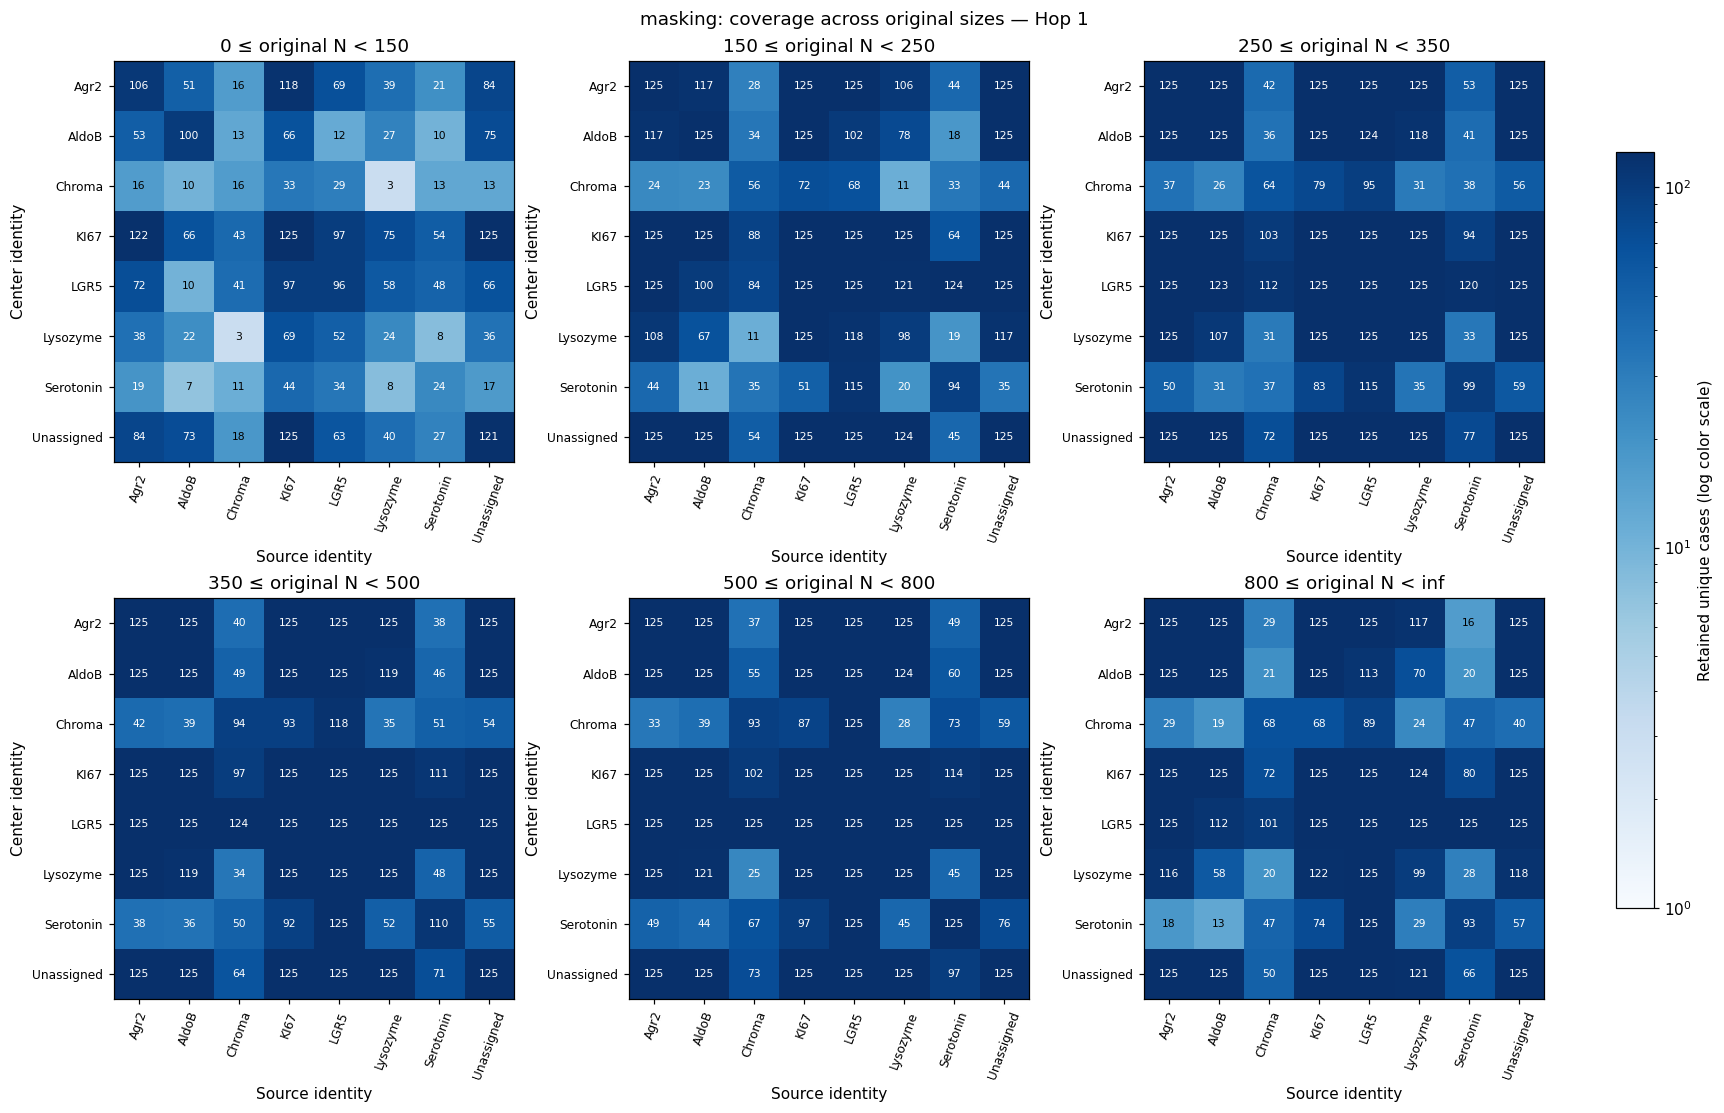

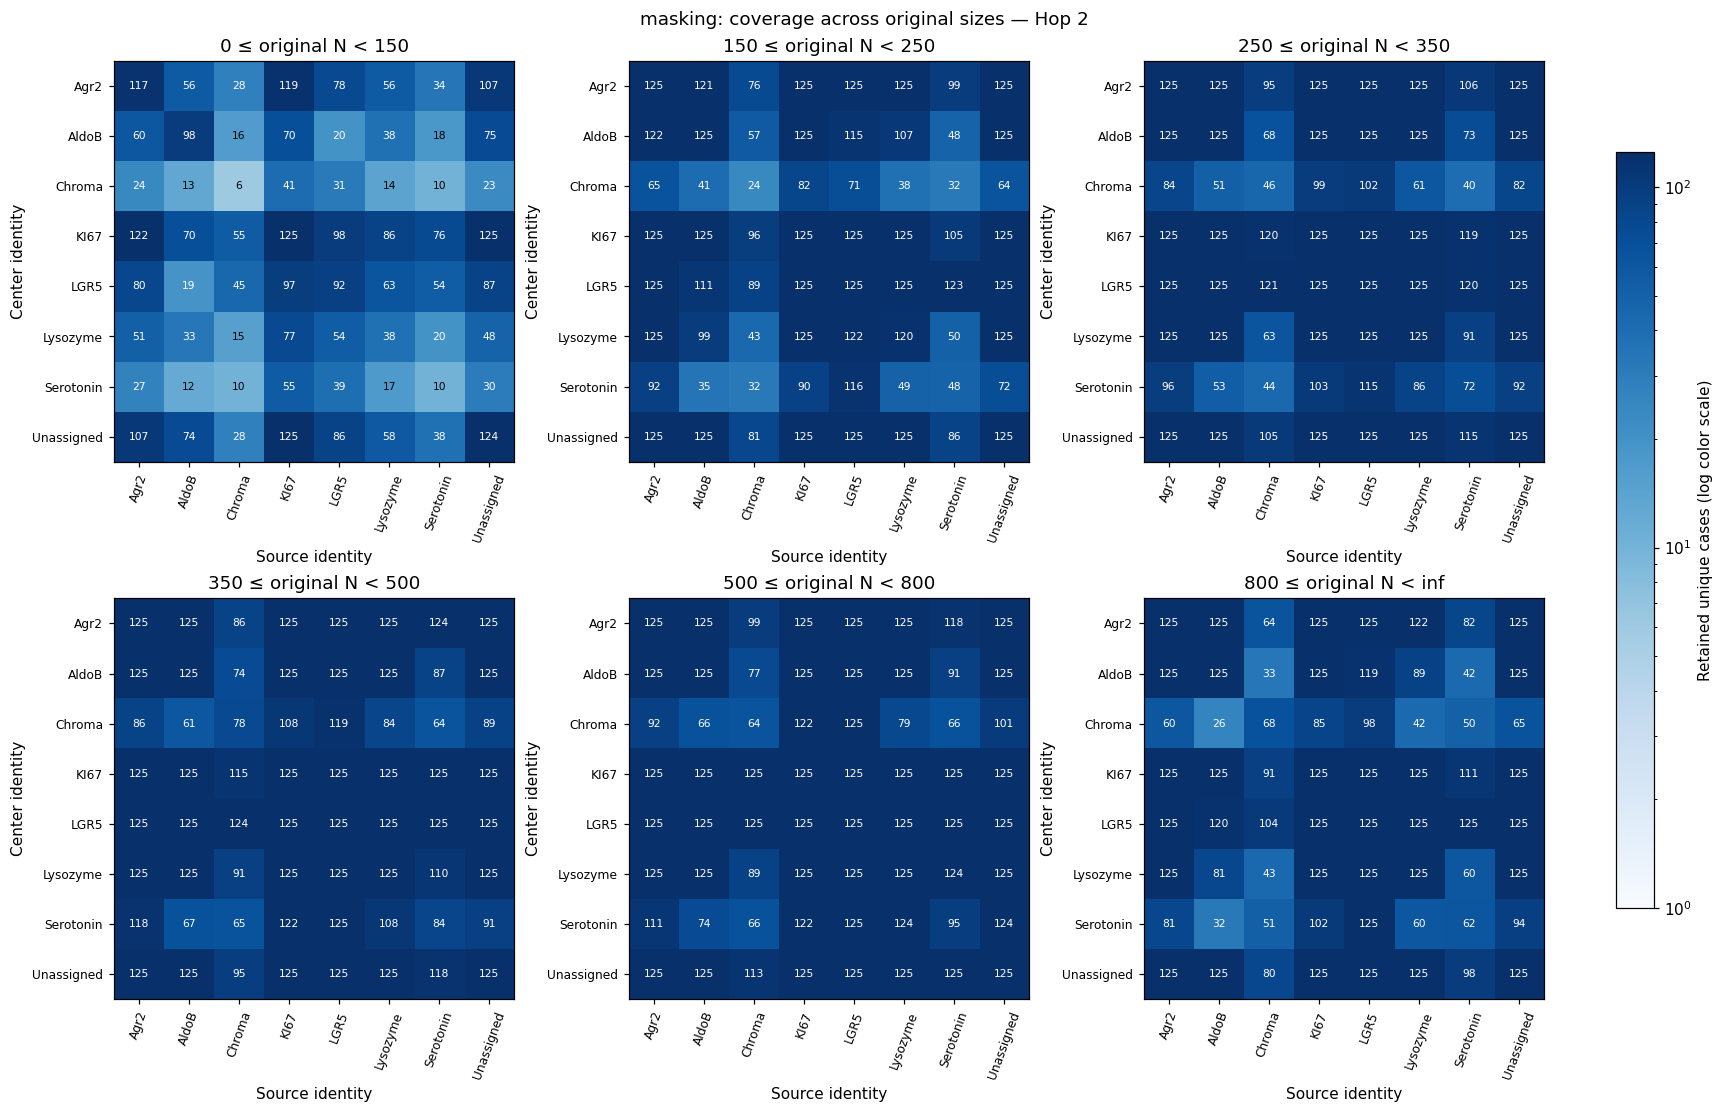

In [6]:
from src.analysis.interventions.fate_edits import count_fate_cases, supported_effects, expand_recipients
from matplotlib.colors import LogNorm
pair_counts = count_fate_cases(cases,metric='delta_mu',size_bins=SIZE_BINS)
pair_counts.to_csv(PLOT_OUTPUT_DIR/'pair_sample_counts.csv',index=False)

# Summarize actual retained cases by original N; discard seed replication.
observed_cases = expand_recipients(supported_effects(cases))
observed_cases = observed_cases[observed_cases.analysis=='observed'].copy()
observed_cases['size_bin'] = pd.cut(observed_cases.observed_n,SIZE_BINS,labels=False,right=False)
size_keys = ['size_bin','hop','center_marker','source_marker_name']
unique_cases = observed_cases.drop_duplicates(size_keys+['organoid_str','orig_center','orig_source_node'])
size_counts = unique_cases.groupby(size_keys,observed=True).agg(
    n_cases=('case_id','size'),n_organoids=('organoid_str','nunique')).reset_index()
size_counts.to_csv(PLOT_OUTPUT_DIR/'retained_size_pair_counts.csv',index=False)
if SAMPLING_SCHEME == 'size_stratified':
    sampling_size_coverage = pd.concat([pd.read_csv(OUTPUT_DIR/'support'/f'{record.key}_size_pair_coverage.csv.gz')
        .assign(fold=record.fold,seed=record.seed) for record in records.itertuples()],ignore_index=True)
    sampling_size_coverage.to_csv(PLOT_OUTPUT_DIR/'sampling_size_pair_coverage.csv',index=False)
    audit = sampling_size_coverage.drop_duplicates(['fold',*size_keys])
    print(f"Per-fold pair/hop/bin targets met: {int(audit.target_met.sum())} / {len(audit)}; "
          f"{int((audit.available_cases==0).sum())} combinations have no available cases.")

# Notebook-specific layout: each hop shows all original-N bins together.
count_limit = max(2,float(size_counts.n_cases.max())) if not size_counts.empty else 2
count_norm = LogNorm(vmin=1,vmax=count_limit)
count_cmap = plt.get_cmap('Blues').copy()
count_cmap.set_bad('white')
bin_count = len(SIZE_BINS)-1
columns = min(3,bin_count)
for hop in HOPS:
    fig,axes = plt.subplots(int(np.ceil(bin_count/columns)),columns,
        figsize=(5.2*columns,5.0*int(np.ceil(bin_count/columns))),squeeze=False,constrained_layout=True)
    for size_bin,ax in enumerate(axes.flat):
        if size_bin >= bin_count:
            ax.set_visible(False)
            continue
        selected = size_counts[(size_counts.hop==hop)&(size_counts.size_bin==size_bin)]
        matrix = selected.pivot(index='center_marker',columns='source_marker_name',values='n_cases').reindex(
            index=PLOT_IDENTITIES,columns=PLOT_IDENTITIES).fillna(0).to_numpy(float)
        mesh = ax.imshow(np.ma.masked_less_equal(matrix,0),cmap=count_cmap,norm=count_norm)
        for row,column in np.ndindex(matrix.shape):
            count = int(matrix[row,column])
            color = 'white' if count and np.mean(count_cmap(count_norm(count))[:3]) < .55 else 'black'
            ax.text(column,row,str(count),ha='center',va='center',fontsize=7,color=color)
        lower,upper = SIZE_BINS[size_bin:size_bin+2]
        ax.set(title=f'{lower:g} ≤ original N < {upper:g}',xlabel='Source identity',ylabel='Center identity',
            xticks=range(len(PLOT_IDENTITIES)),xticklabels=PLOT_IDENTITIES,
            yticks=range(len(PLOT_IDENTITIES)),yticklabels=PLOT_IDENTITIES)
        ax.tick_params(axis='x',rotation=70,labelsize=8)
        ax.tick_params(axis='y',labelsize=8)
    fig.colorbar(mesh,ax=[ax for ax in axes.flat if ax.get_visible()],label='Retained unique cases (log color scale)',shrink=.8)
    fig.suptitle(f'{ABLATION_TYPE}: coverage across original sizes — Hop {hop}')
    fig.savefig(PLOT_OUTPUT_DIR/f'size_bin_coverage_hop{hop}.png',dpi=160,bbox_inches='tight')
    plt.show()


## Depth-0 reference and normalization support

Inspect the reference itself before interpreting ratios. The left panel shows median reconstructed total curvature across sampled organoids for each center identity at the supplied sweep sizes; the saved observed baseline accounts for between-organoid variation. The right panel shows the fraction of distinct organoid/center cases retained at all sweep sizes after the near-zero cutoff. The reference curve is descriptive, not an additional ablation effect.

`depth0_support.csv` compares retained pair counts for raw and reference-normalized effects after their respective all-N support checks. `depth0_exclusions.csv` records per-size exclusions. These tables distinguish an absent source identity from a reference denominator too close to zero. No numbers are written inside response heatmaps.

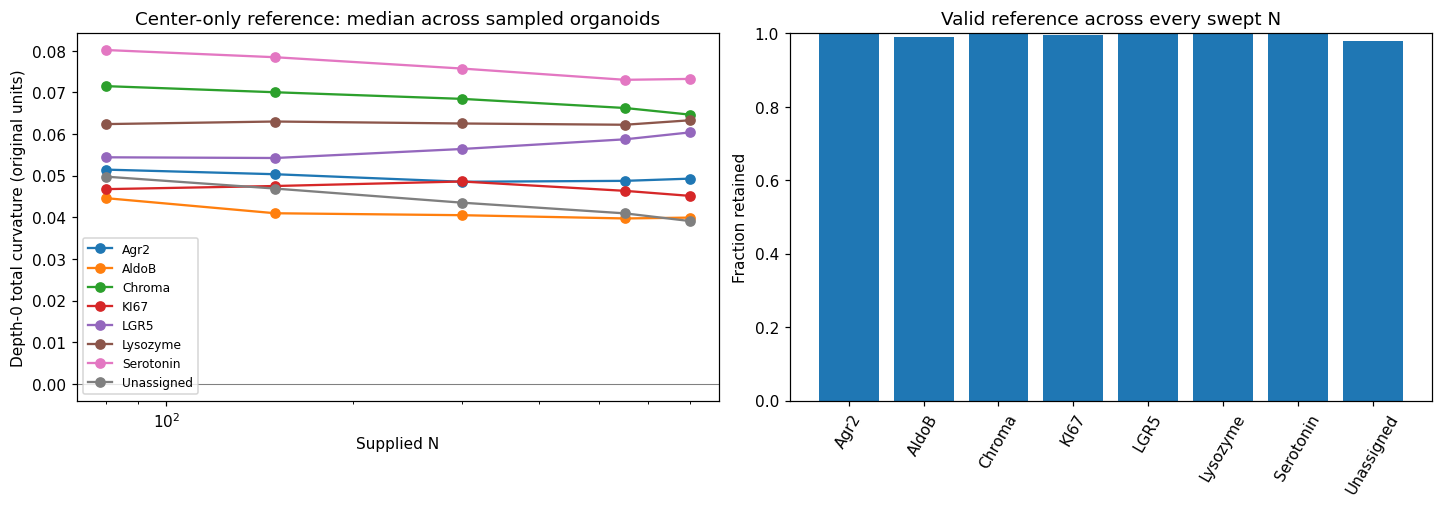

In [7]:
if DEPTH0_NORMALIZATION:
    depth0_support = pd.concat([count_fate_cases(cases,metric=metric,size_bins=SIZE_BINS).assign(metric=metric)
        for metric in ('delta_mu','delta_depth0_relative')],ignore_index=True)
    depth0_support.to_csv(PLOT_OUTPUT_DIR/'depth0_support.csv',index=False)
    reference_cases = expand_recipients(cases)
    reference_units = reference_cases.drop_duplicates(
        ['model_key','organoid_str','orig_center','center_marker','analysis','evaluated_n'])
    exclusions = reference_units.groupby(['analysis','evaluated_n','center_marker'],observed=True).agg(
        n_centers=('orig_center','size'),invalid=('depth0_valid',lambda valid:int((~valid).sum())),
        min_abs_reference=('depth0_curvature',lambda values:values.abs().min())).reset_index()
    exclusions.to_csv(PLOT_OUTPUT_DIR/'depth0_exclusions.csv',index=False)
    swept_reference = reference_units[reference_units.analysis=='sweep'].copy()
    # Average fitted seeds within the original organoid; one vote per identity/organoid.
    org_reference = swept_reference.groupby(['organoid_str','center_marker','evaluated_n'],observed=True).depth0_curvature.mean().reset_index()
    reference_curve = org_reference.groupby(['center_marker','evaluated_n'],observed=True).depth0_curvature.median().reset_index()
    valid_across_sweep = swept_reference.groupby(['model_key','organoid_str','orig_center','center_marker'],observed=True).depth0_valid.all().reset_index()
    valid_fraction = valid_across_sweep.groupby('center_marker',observed=True).depth0_valid.mean()
    fig,axes = plt.subplots(1,2,figsize=(13,4.5),constrained_layout=True)
    for marker,part in reference_curve.groupby('center_marker',sort=False):
        axes[0].plot(part.evaluated_n,part.depth0_curvature,'o-',label=marker)
    axes[0].axhline(0,color='grey',lw=.7)
    axes[0].set(xscale='log',xlabel='Supplied N',ylabel='Depth-0 total curvature (original units)',
        title='Center-only reference: median across sampled organoids')
    axes[0].legend(fontsize=8)
    axes[1].bar(valid_fraction.index,valid_fraction.values)
    axes[1].set(ylim=(0,1),ylabel='Fraction retained',title='Valid reference across every swept N')
    axes[1].tick_params(axis='x',rotation=60)
    fig.savefig(PLOT_OUTPUT_DIR/'depth0_reference_and_support.png',dpi=160,bbox_inches='tight')
    plt.show()

## Summarize and plot

Average cases and seeds within organoids. Observed curves then average organoids within their own N bins. With `SWEEP_WEIGHTING='equal_size_bins'`, sweep curves average organoids within original-size bins, then give those bins equal weight. Bootstrap organoids separately within each bin, retaining fixed bin weights. Bins below `SWEEP_MIN_ORGANOIDS_PER_BIN` organoids are omitted for that pair/hop throughout the sweep; `size_bins_used` and `n_size_bins` in the summary identify the represented size ranges. Thus rare pairs can represent fewer bins: broad coverage is a goal, not a claim that missing identities exist. Bands/tables give pointwise organoid-bootstrap intervals conditional on trained models. Cells below MIN_PLOT_CASES retained cases are white and hatched in heatmaps; size curves have gaps at insufficiently supported bins. The default requires at least five cases and five organoids per point; sampling aims for a higher quota. A per-hop case-threshold dictionary is also supported. Counts refer to unique physical recipient/source cases after non-overlap and donor support, not repeated model seeds or sweep points. MIN_PLOT_ORGANOIDS is an additional independent threshold. The summary exports these counts as n_cases. For sweeps, retain only source cases supported at every supplied N; report support before interpreting their curves. Positive effects mean edited minus intact prediction is positive. These are predictor contrasts, not causal cell interactions.

Observed and sweep curves use distinct colors, with matching uncertainty bands. Observed curves also use solid lines and circles; sweeps use dashed lines and squares. Each figure title identifies the exact hop distance.

### Raw and sphere-relative curvature changes

For each fold, fit log surface area against log N using its training organoids only: $\widehat A_f(N)=\exp(\alpha_f)N^{\beta_f}$. The reference sphere has Gaussian curvature $K_{\mathrm{ref},f}(N)=4\pi/\widehat A_f(N)$. The relative effect is $\Delta K/K_{\mathrm{ref},f}(N)$: 0.2 means an increase equal to 20% of that reference curvature.

Normalize each case before averaging. Observed cases use observed N; sweeps use supplied N. Both units use identical predictions, cases, support thresholds and bootstrap settings. The positive geometric reference does not change individual effect signs. Produce a separate raw and relative figure for each hop, with the units in the title and y-axis labels; all summaries are saved in `size_summary.csv` with a `metric` column.

### Center-reference curvature changes

The additional `delta_depth0_relative` panels show $\Delta K/|K_0|$ using the reconstructed depth-0 reference above. For example, +0.2 means an increase equal to 20% of the magnitude of the center-only reference. Its denominator exclusions can reduce support compared with the raw and sphere-relative panels; inspect the preceding support diagnostic. Bootstrap intervals condition on both trained models and the fitted reference.


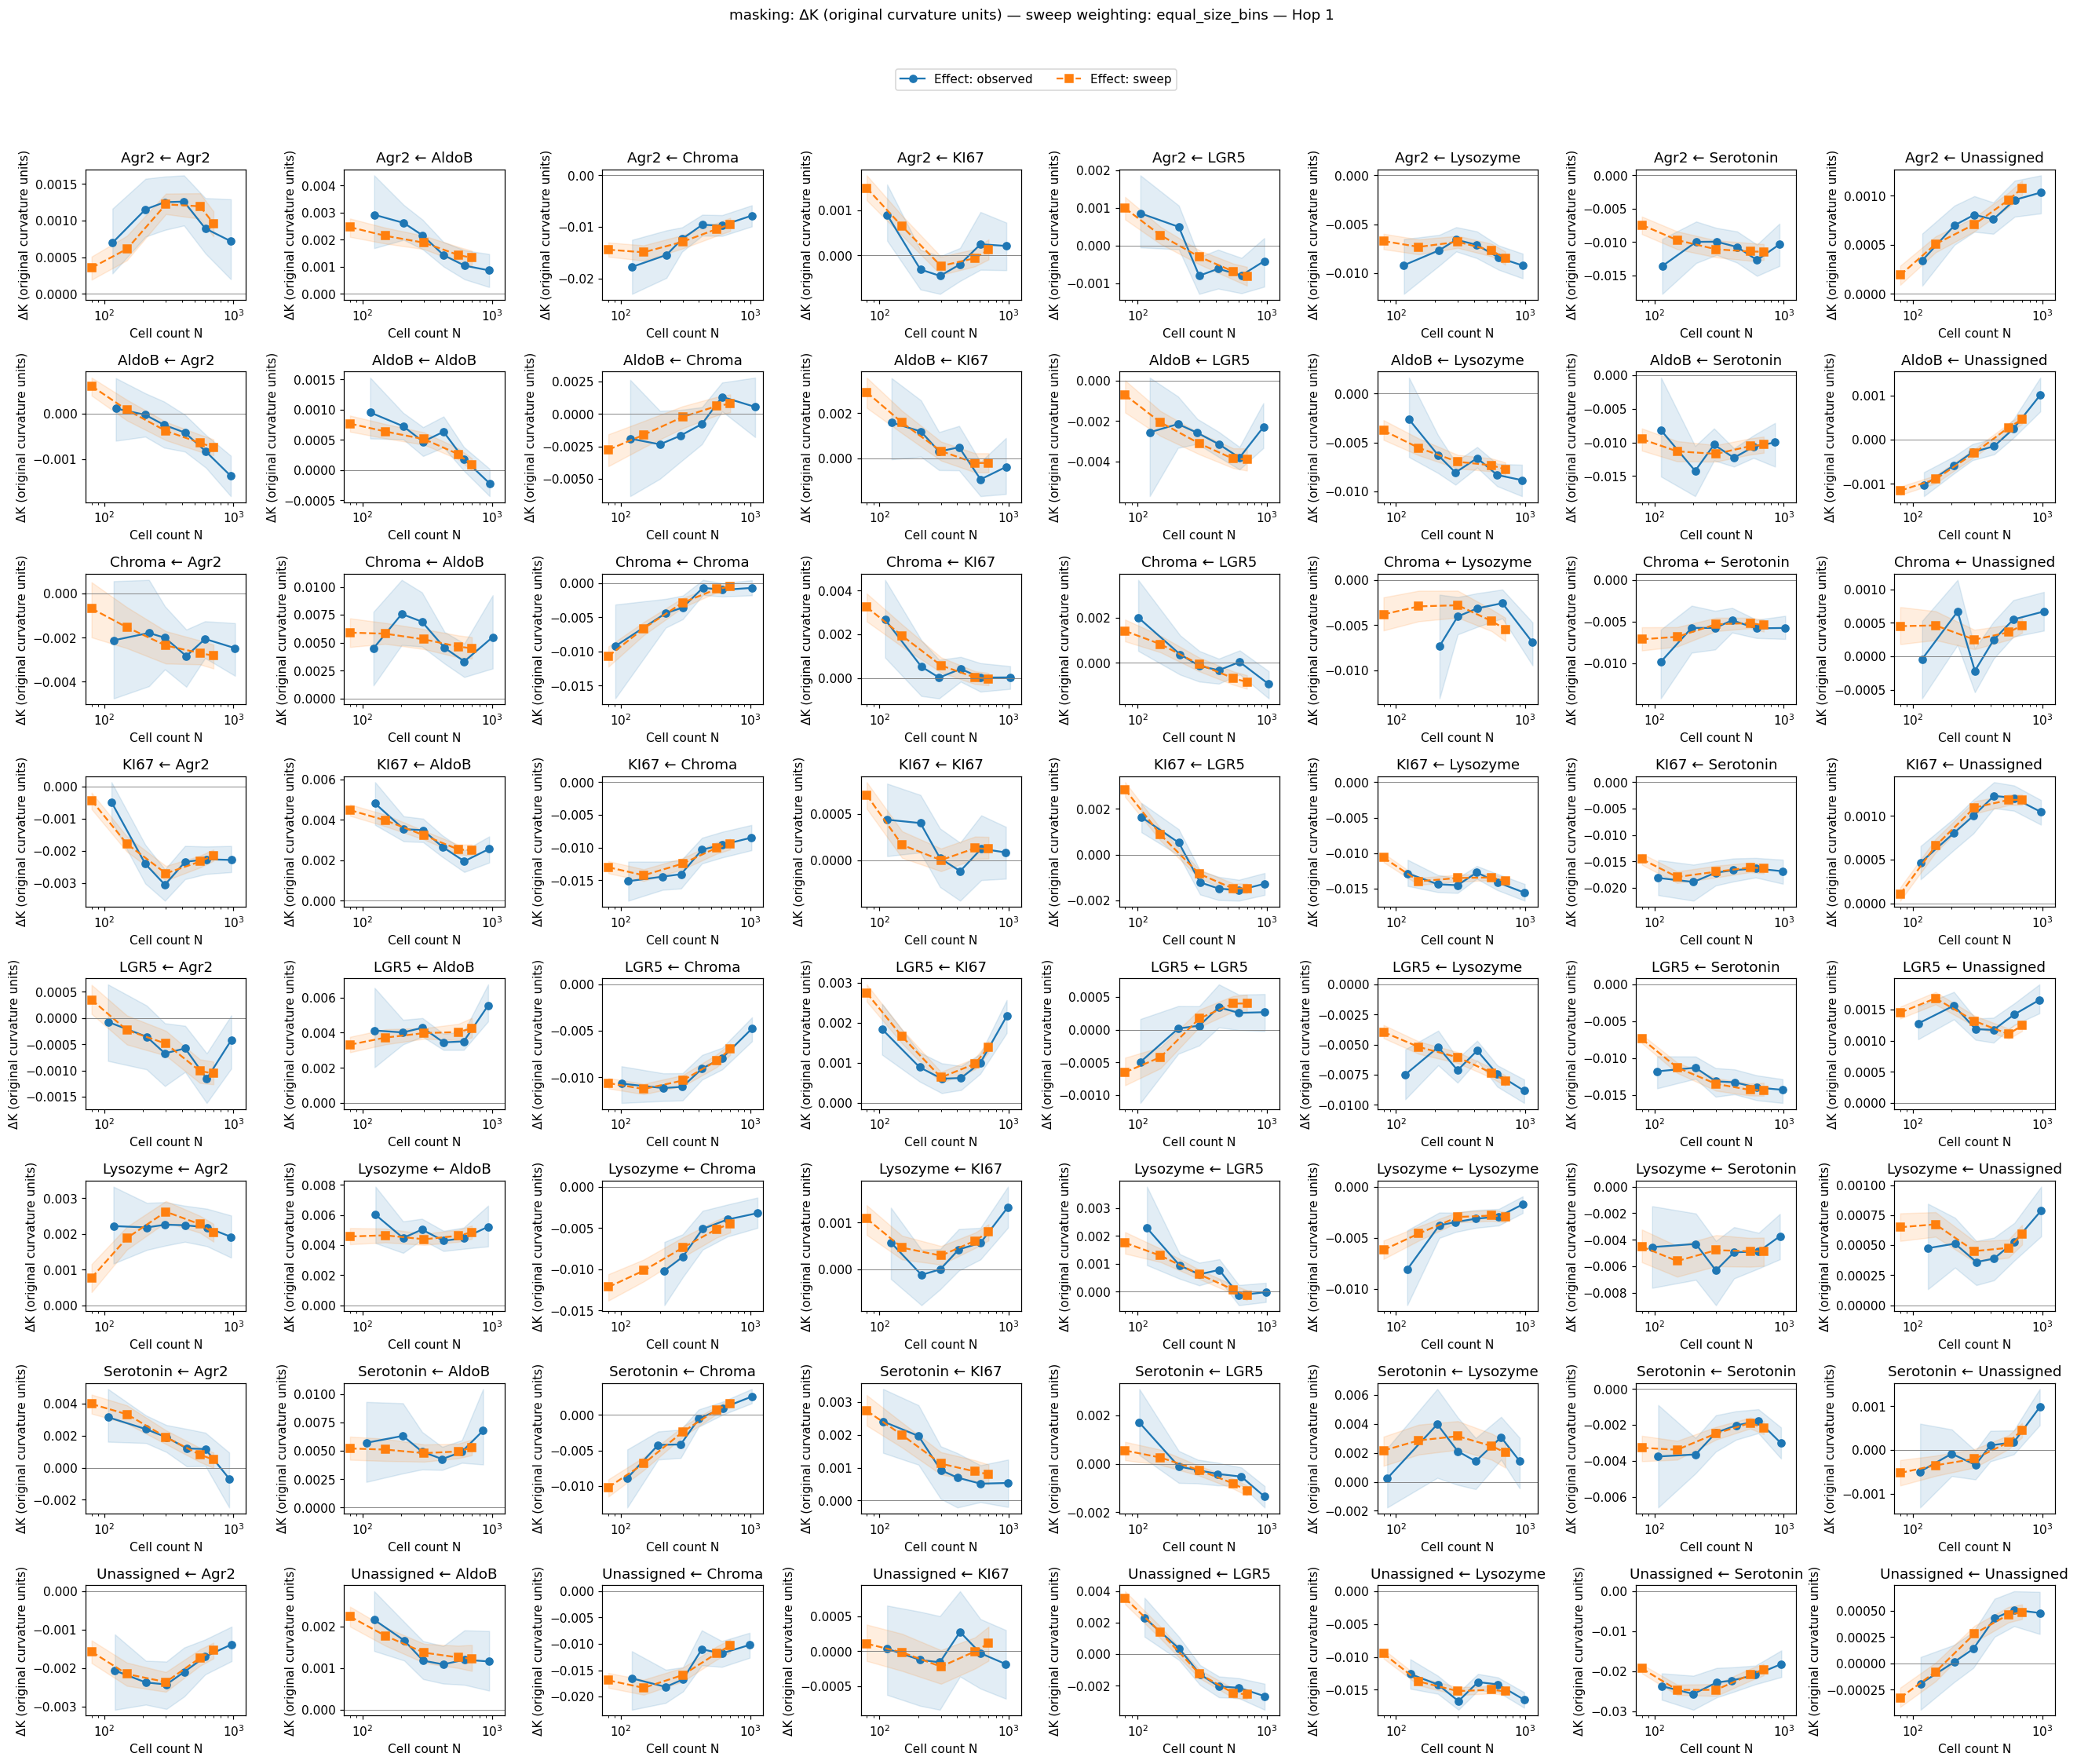

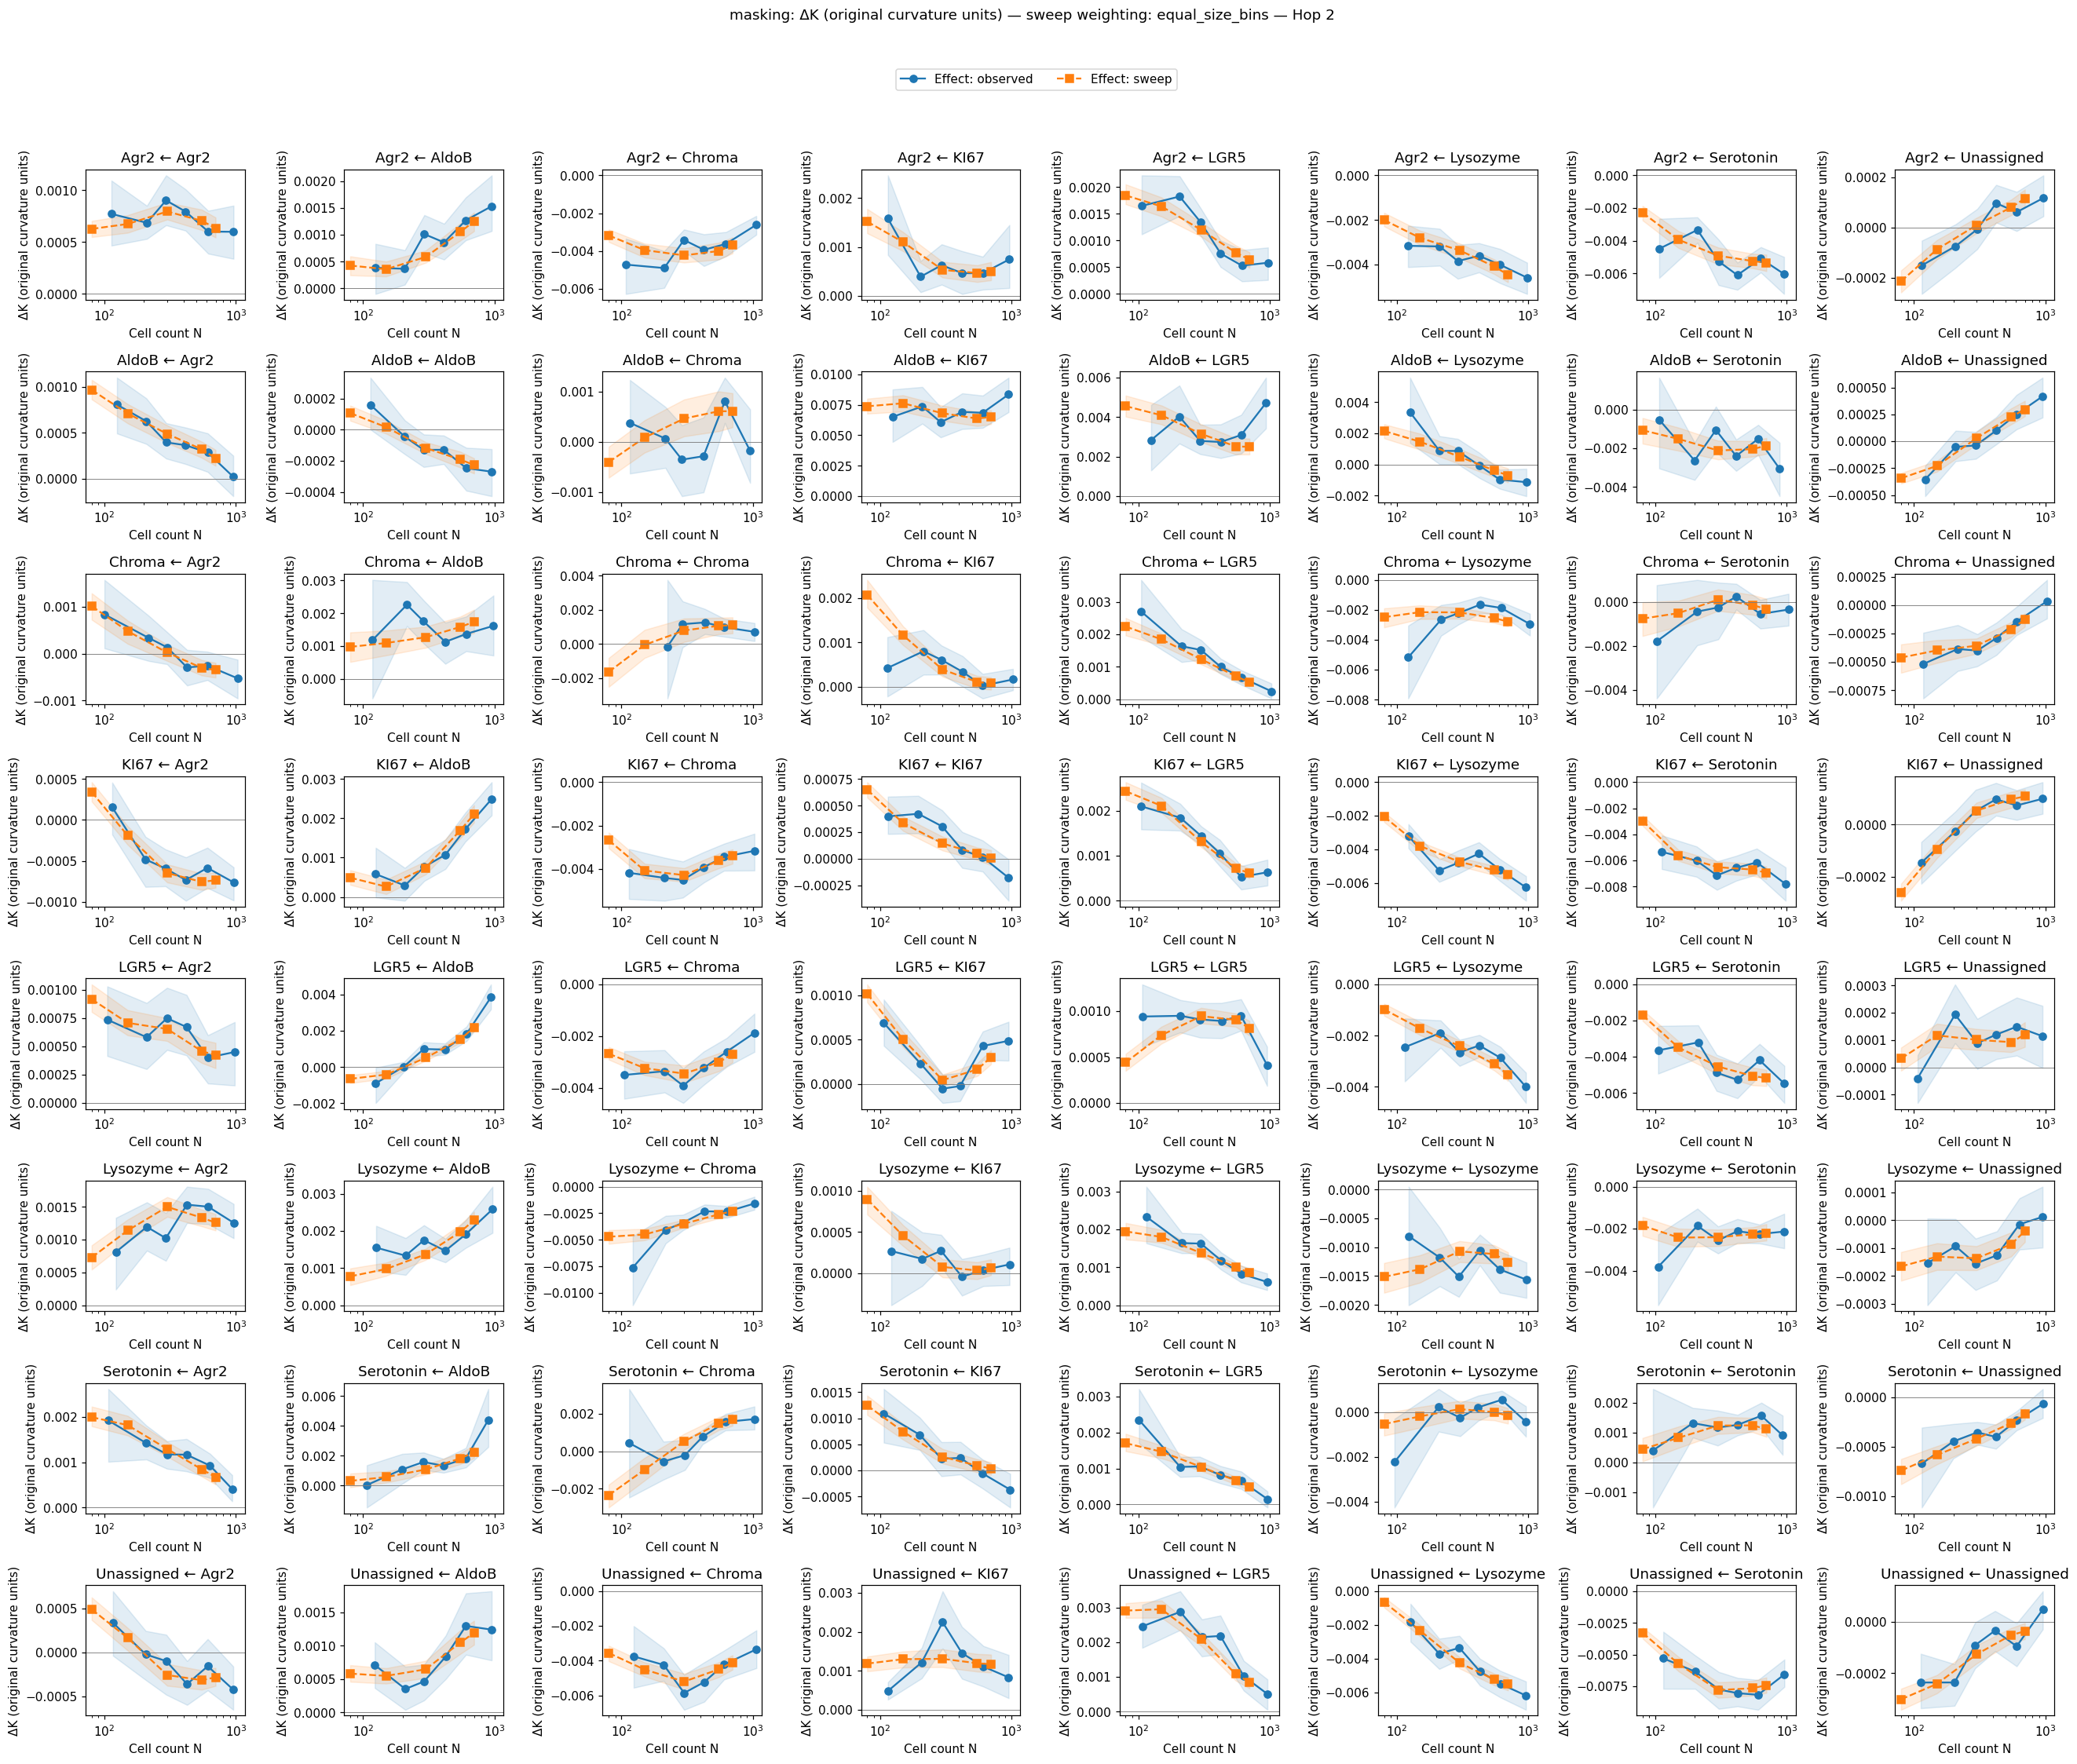

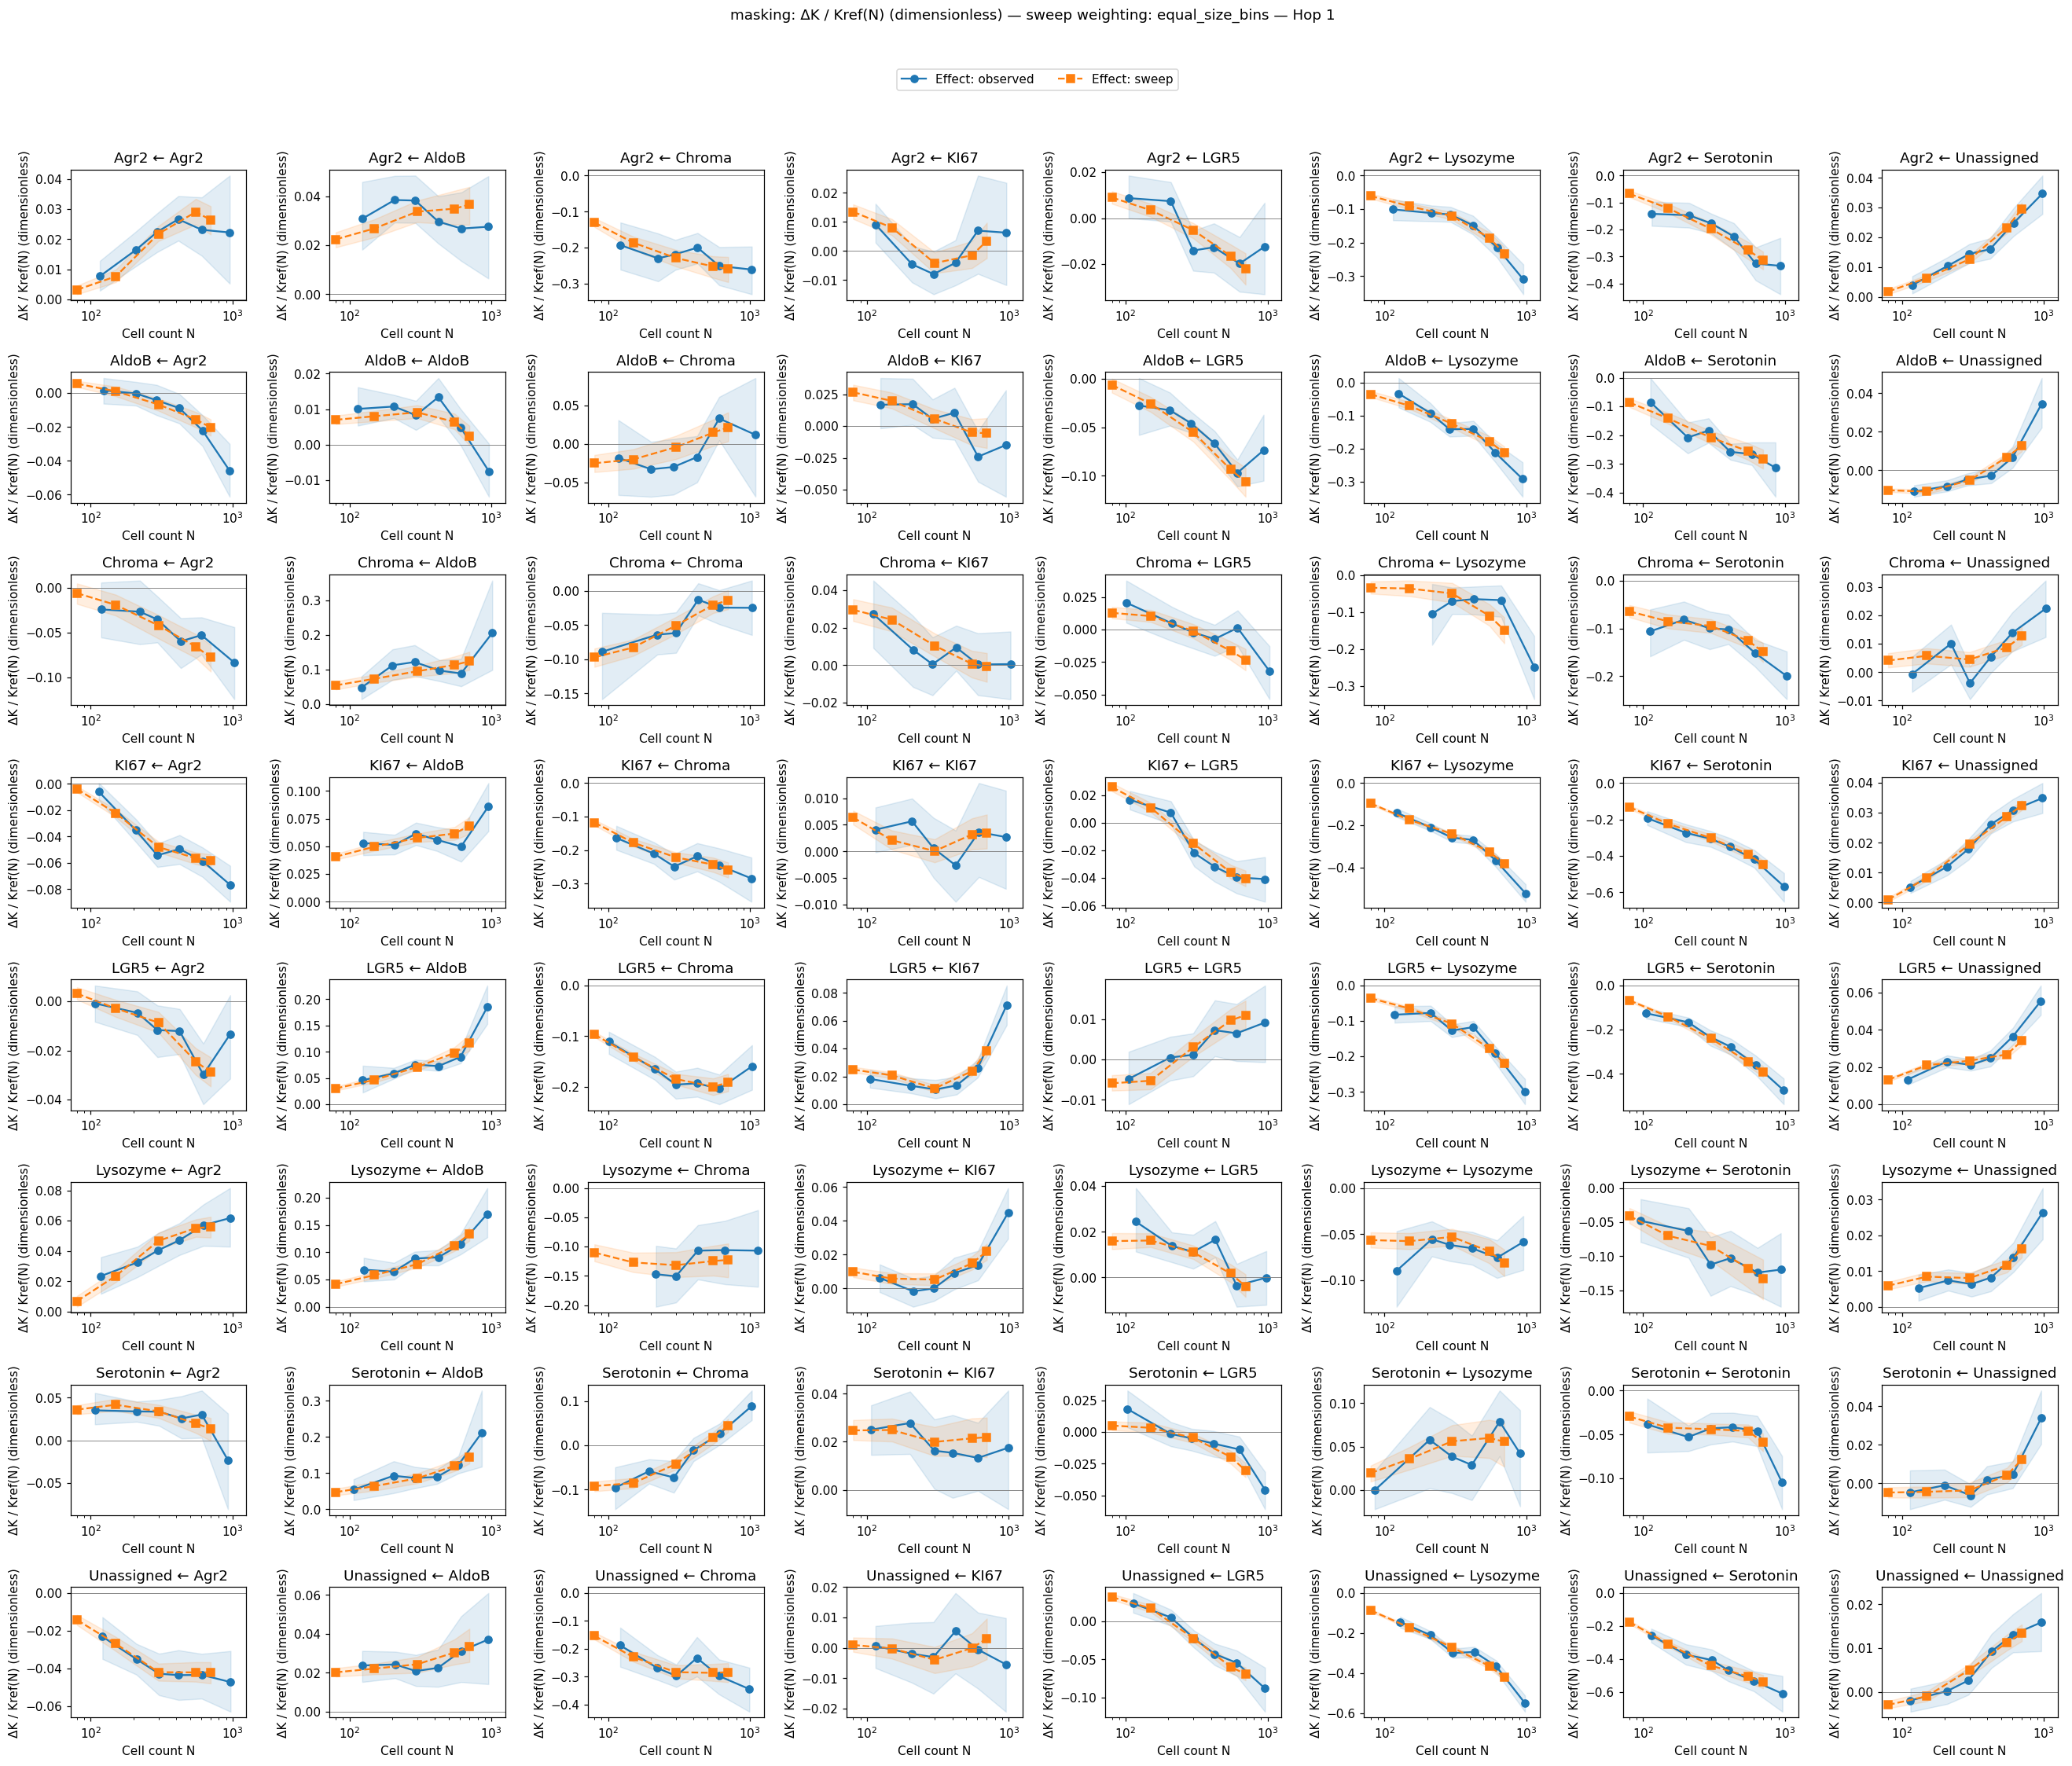

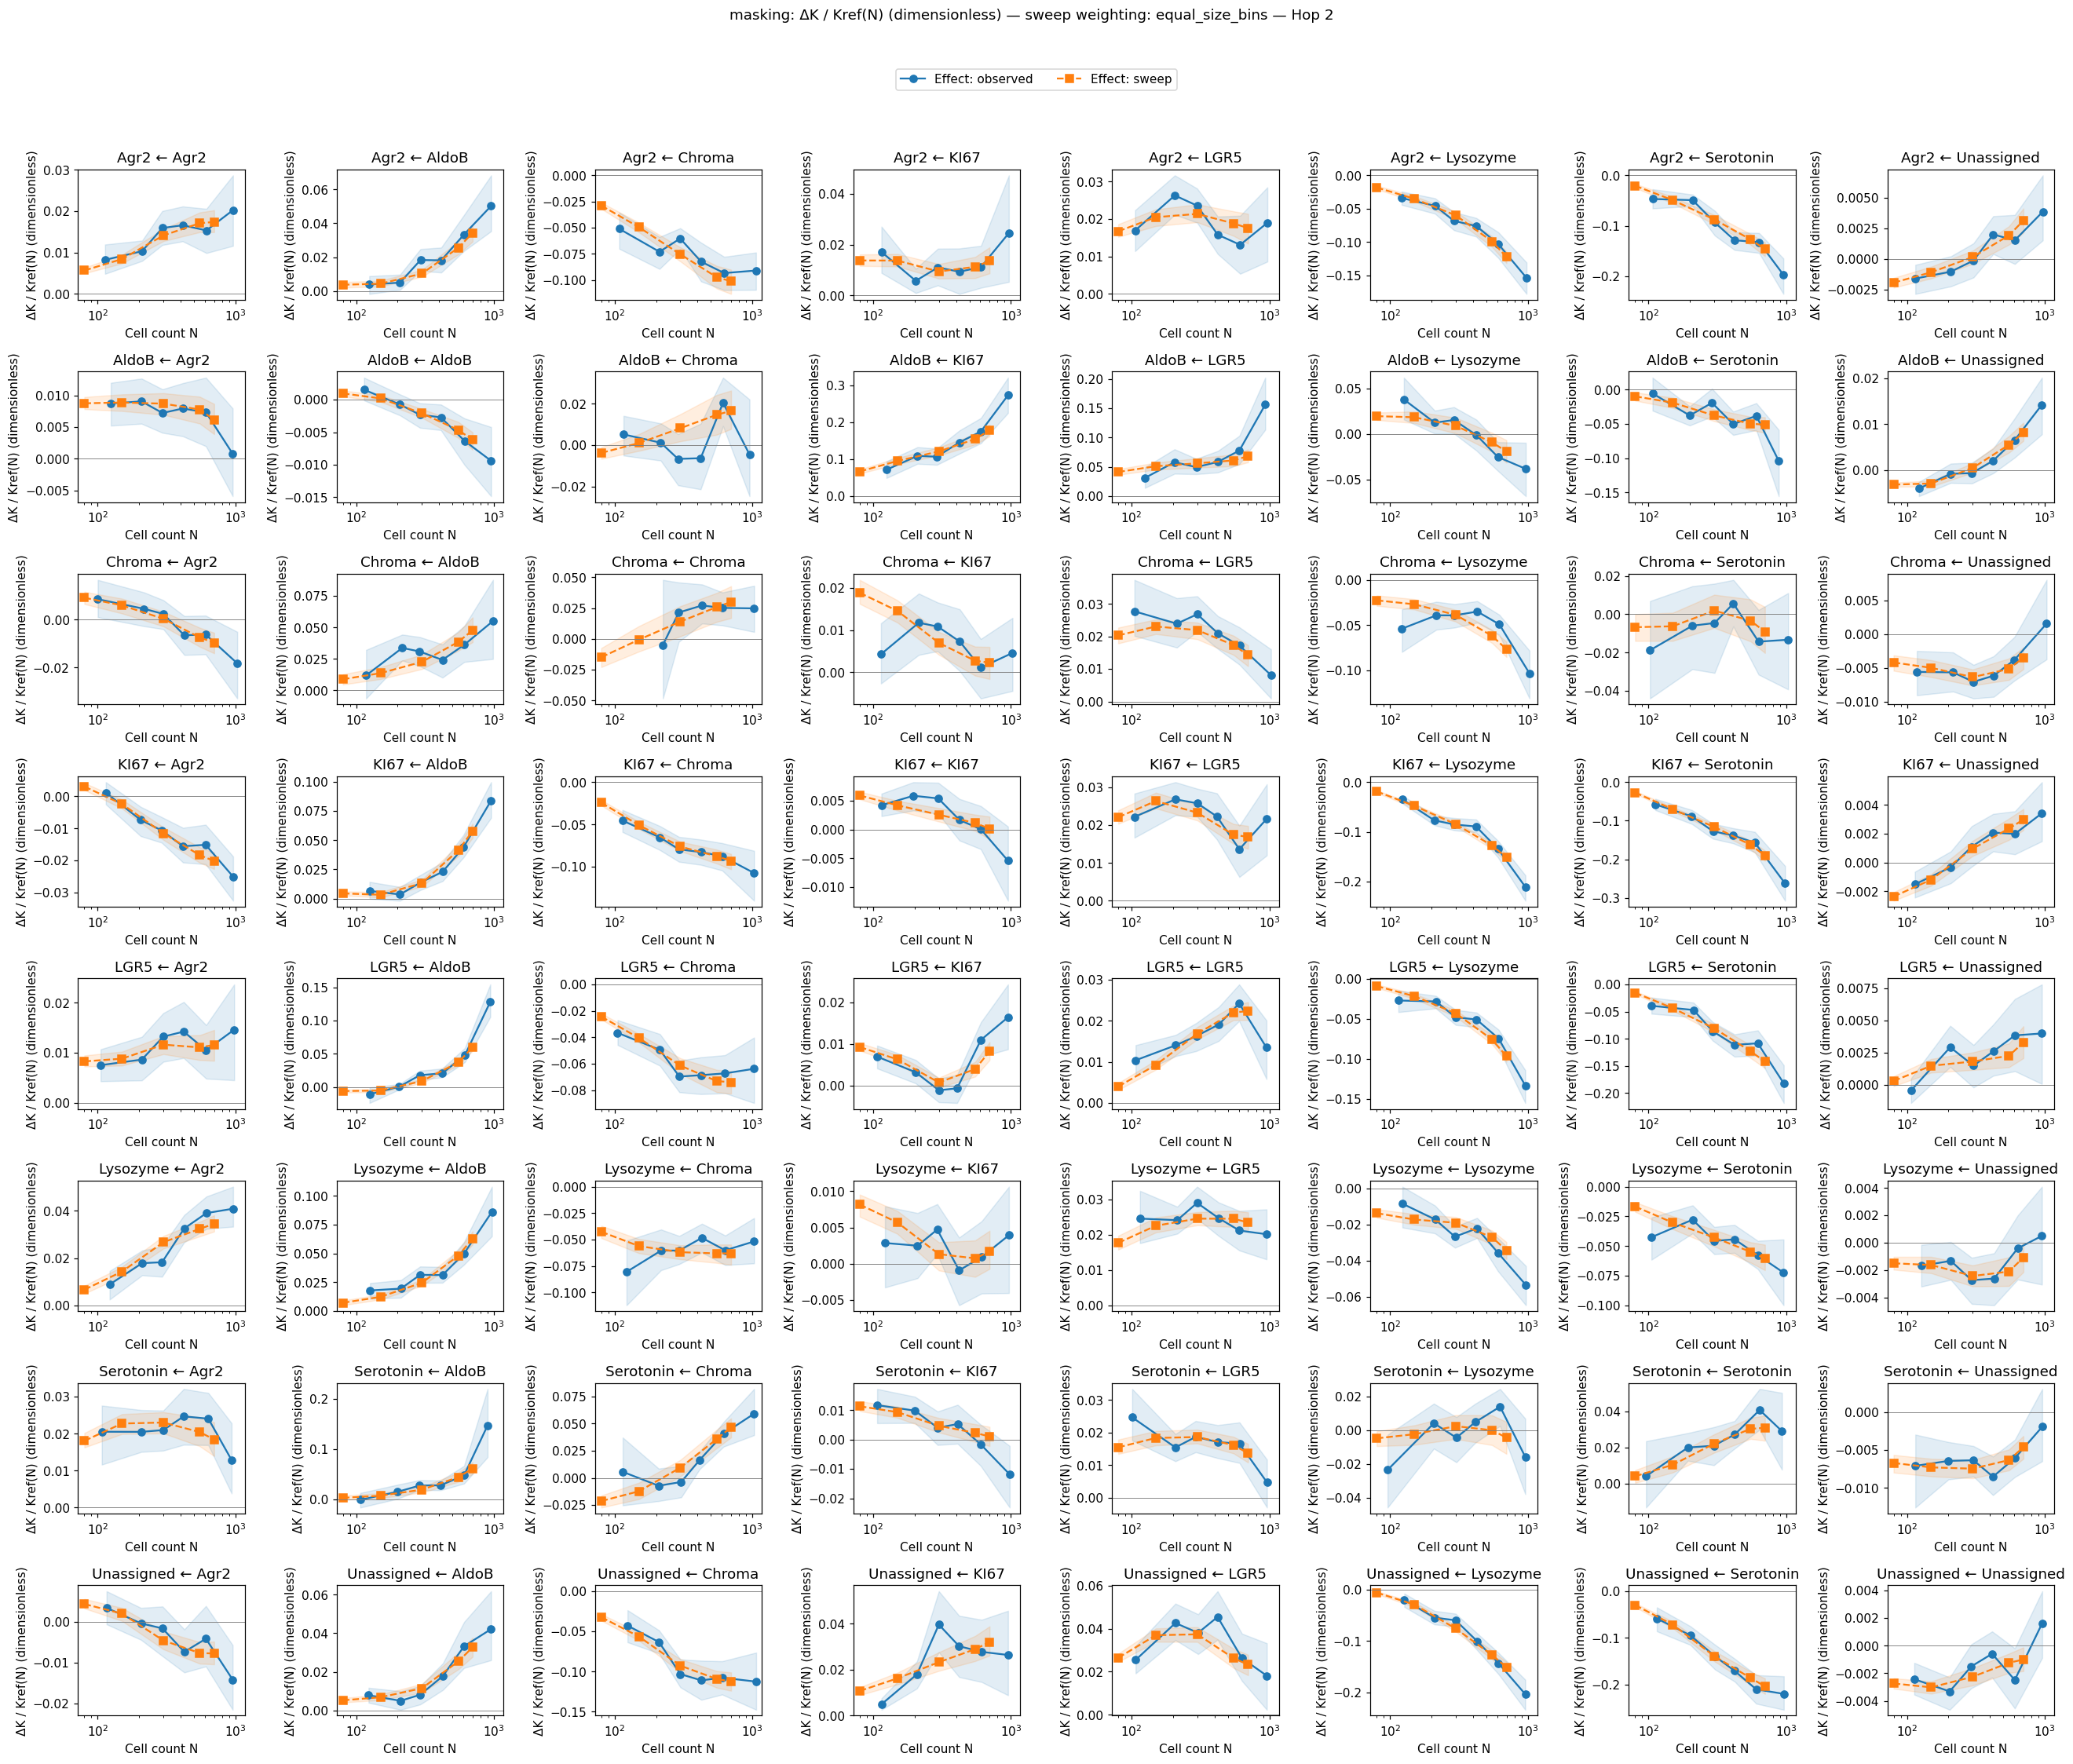

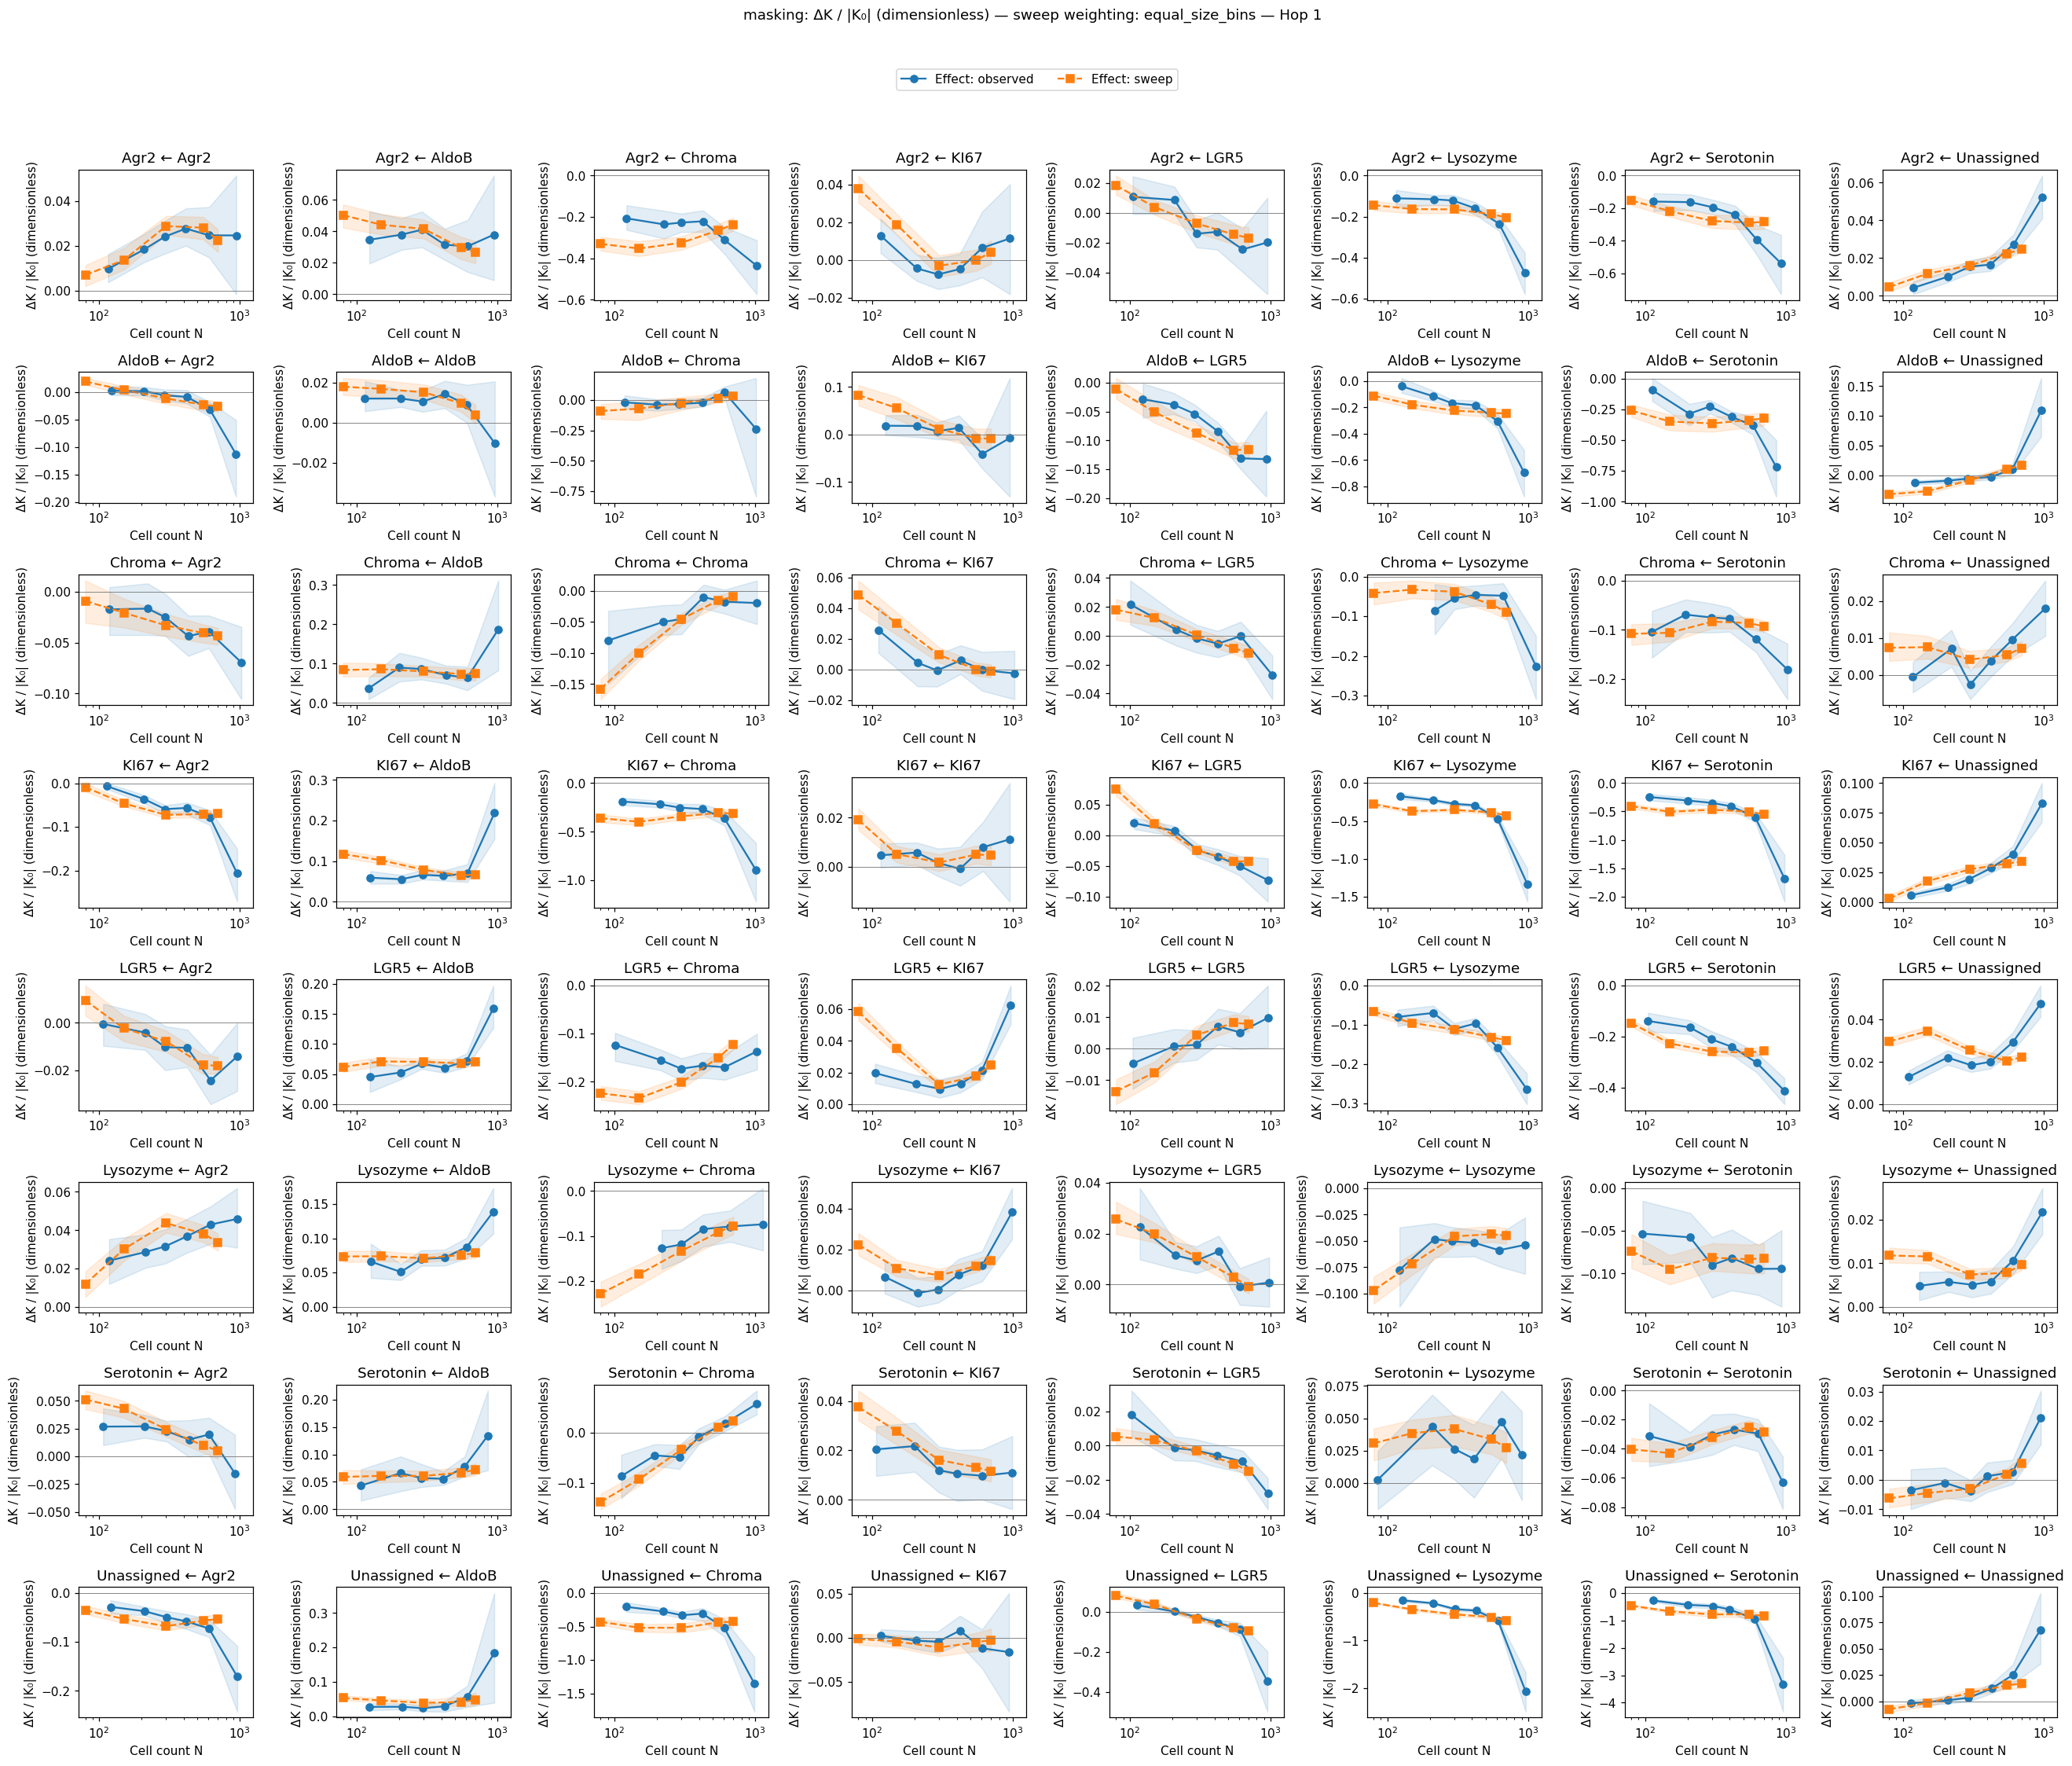

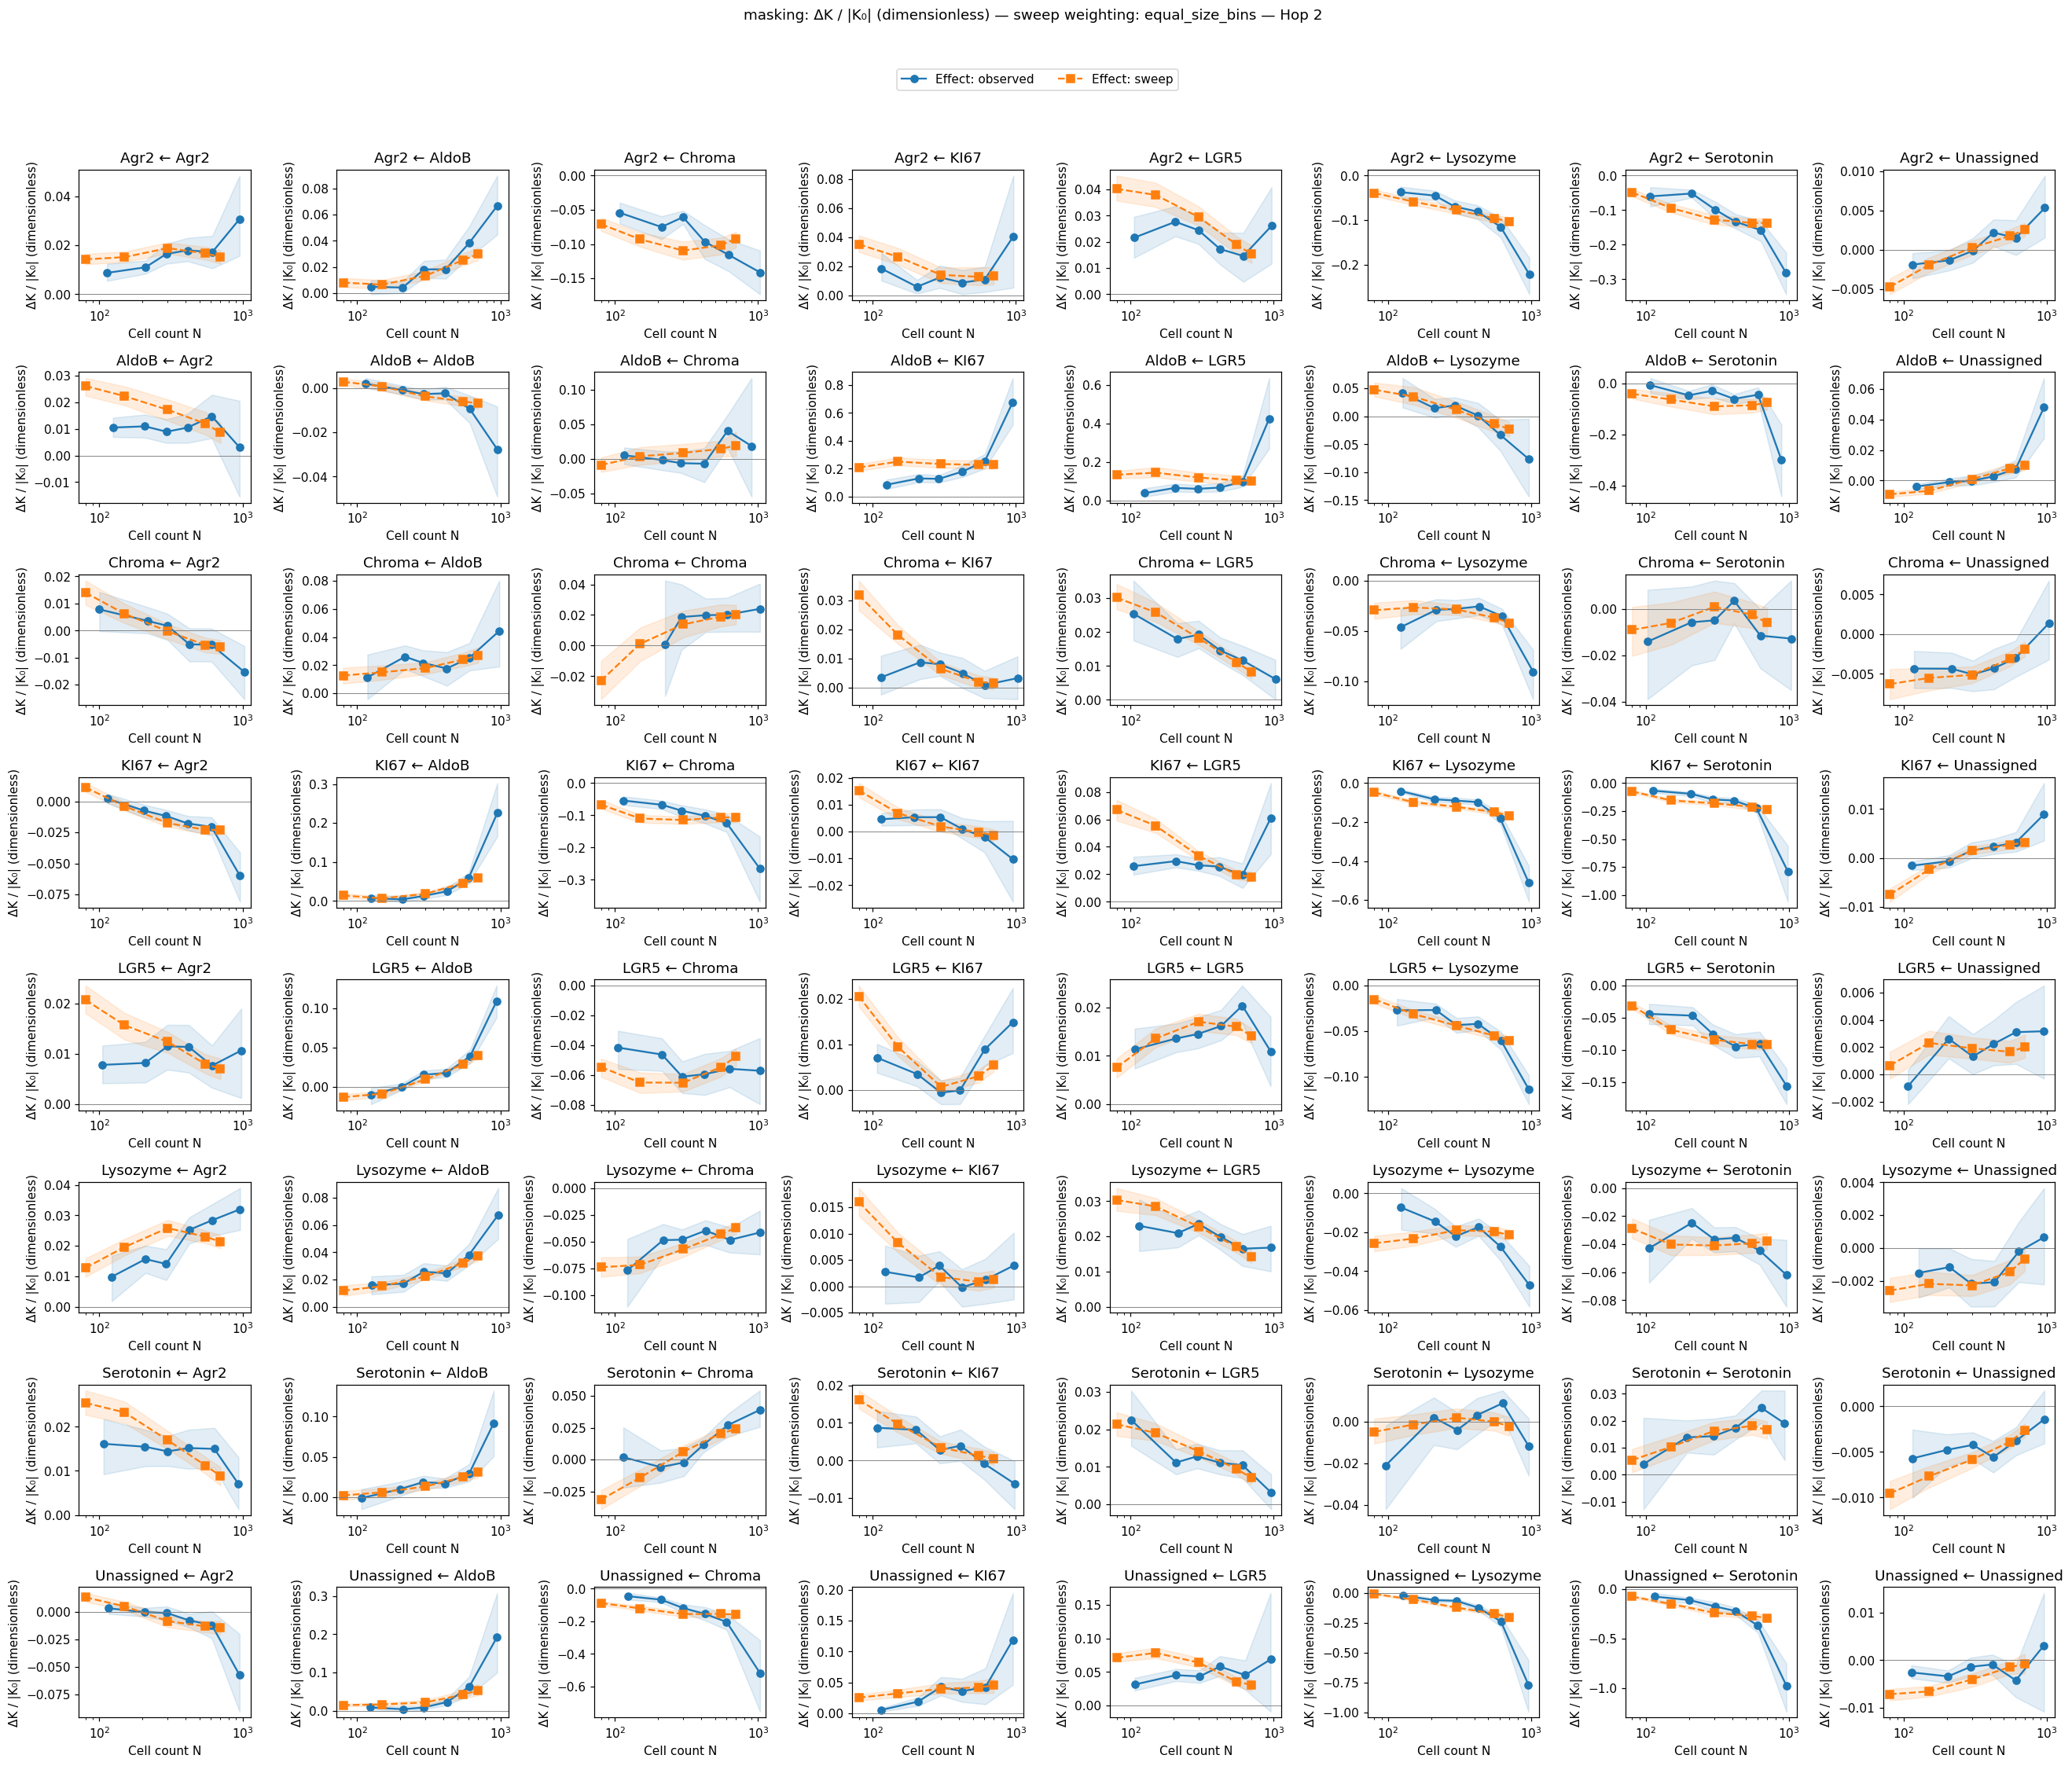

In [8]:
from src.plotting.influence_maps import plot_pair_size_curves
(PLOT_OUTPUT_DIR/'plot_settings.json').write_text(json.dumps(dict(
    metrics=PLOT_METRICS,heatmap_display_min_cases=MIN_PLOT_CASES,
    sweep_weighting=SWEEP_WEIGHTING,sweep_min_organoids_per_bin=SWEEP_MIN_ORGANOIDS_PER_BIN,
    min_plot_organoids=MIN_PLOT_ORGANOIDS,bootstrap_samples=BOOTSTRAP_SAMPLES),indent=2))
metric_labels = {
    'delta_mu': 'ΔK (original curvature units)',
    'delta_relative': 'ΔK / Kref(N) (dimensionless)',
    'delta_depth0_relative': 'ΔK / |K₀| (dimensionless)',
    'delta_z': 'Δ transformed curvature',
}
summaries = []
for metric in PLOT_METRICS:
    metric_summary = summarize_fate_effects(cases,view='size',metric=metric,size_bins=SIZE_BINS,
        draws=BOOTSTRAP_SAMPLES,seed=SAMPLING_SEED,sweep_weighting=SWEEP_WEIGHTING,
        sweep_min_organoids_per_bin=SWEEP_MIN_ORGANOIDS_PER_BIN)
    summaries.append(metric_summary.assign(metric=metric))
    for hop in HOPS:
        if metric_summary.empty or hop not in metric_summary.hop.values:
            print(f'No supported effects at hop {hop} for {metric}.')
            continue
        fig = plot_pair_size_curves(metric_summary,hop=hop,min_organoids=MIN_PLOT_ORGANOIDS,
            min_cases=MIN_PLOT_CASES,ylabel=metric_labels[metric],
            title=f'{ABLATION_TYPE}: {metric_labels[metric]} — sweep weighting: {SWEEP_WEIGHTING}')
        for legend in fig.legends:
            legend.set_bbox_to_anchor((0.5,0.985))
        fig.savefig(PLOT_OUTPUT_DIR/f'hop{hop}_{metric}.png',dpi=160,bbox_inches='tight')
        plt.show()
summary = pd.concat(summaries,ignore_index=True)
summary.to_csv(PLOT_OUTPUT_DIR/'size_summary.csv',index=False)
